# Stock Market Trend Analysis

In [3]:
#importing relevant libraries 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [4]:
#loading relevant dataset
stk_prices_indicators = pd.read_csv(r'C:\Users\ofori\OneDrive\Desktop\Stock_Market_Analysis\Stock-analysis\data\stock_prices_with_indicators.csv')

In [4]:
#Applying data quality assessment on the stock prices with indicators dataset
stk_prices_indicators['date'] = pd.to_datetime(stk_prices_indicators['date'])

In [5]:
stk_prices_indicators.head()

,ticker,date,open,high,low,close,volume,adjusted_close,sma_20,sma_50,...,true_range,atr_14,volume_sma_20,volume_ratio,momentum_10,momentum_20,price_to_sma_50,volatility_20,future_return_5d,trend_label
0,STK001,2021-01-04,158.09,160.97,158.09,160.11,962644.0,160.11,160.110000,160.110000,...,2.88,2.880,962644.00,1.000000,NaN,NaN,0.000000,NaN,0.026357,Uptrend
1,STK001,2021-01-05,163.16,165.50,160.76,162.36,1312685.0,162.36,161.235000,161.235000,...,5.39,4.135,1137664.50,1.153842,NaN,NaN,0.006977,NaN,0.018169,Sideways
2,STK001,2021-01-06,161.89,162.51,160.94,161.78,1449177.0,161.78,161.416667,161.416667,...,1.57,3.280,1241502.00,1.167277,NaN,NaN,0.002251,0.012463,-0.012301,Sideways
3,STK001,2021-01-07,163.33,167.90,163.33,167.07,1534833.0,167.07,162.830000,162.830000,...,6.12,3.990,1314834.75,1.167320,NaN,NaN,0.026039,0.018138,-0.061950,Downtrend
4,STK001,2021-01-08,168.20,168.20,164.12,165.68,848261.0,165.68,163.400000,163.400000,...,4.08,4.008,1221520.00,0.694431,NaN,NaN,0.013953,0.018663,-0.070196,Downtrend


In [6]:
#Extracting the relevant date information 
stk_prices_indicators['Year'] = stk_prices_indicators['date'].dt.year
stk_prices_indicators['Month'] = stk_prices_indicators['date'].dt.month
stk_prices_indicators['Day'] = stk_prices_indicators['date'].dt.day  

In [9]:
stk_prices_indicators["mnth_yr"] = stk_prices_indicators["mnth_yr"].dt.to_timestamp()


In [10]:
stk_prices_indicators["mnth_yr"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 15502 entries, 0 to 15501
Series name: mnth_yr
Non-Null Count  Dtype         
--------------  -----         
15502 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 121.2 KB


In [10]:
stk_prices_indicators.ticker.nunique()

20

In [11]:
#Setting the date as the index, as this is time series data
stk_prices_indicators.set_index('date', inplace=True)

In [13]:
stk_prices_indicators.ticker.nunique()

20

In [17]:
stk_prices_indicators.ticker.unique()

array(['STK001', 'STK002', 'STK003', 'STK004', 'STK005', 'STK006',
       'STK007', 'STK008', 'STK009', 'STK010', 'STK011', 'STK012',
       'STK013', 'STK014', 'STK015', 'STK016', 'STK017', 'STK018',
       'STK019', 'STK020'], dtype=object)

In [19]:
stk_prices_indicators['open'].describe()

count    15502.000000
mean       102.408860
std         58.524307
min         21.060000
25%         63.350000
50%         88.540000
75%        131.052500
max        512.090000
Name: open, dtype: float64

Text(0.5, 0, 'Opening Price')

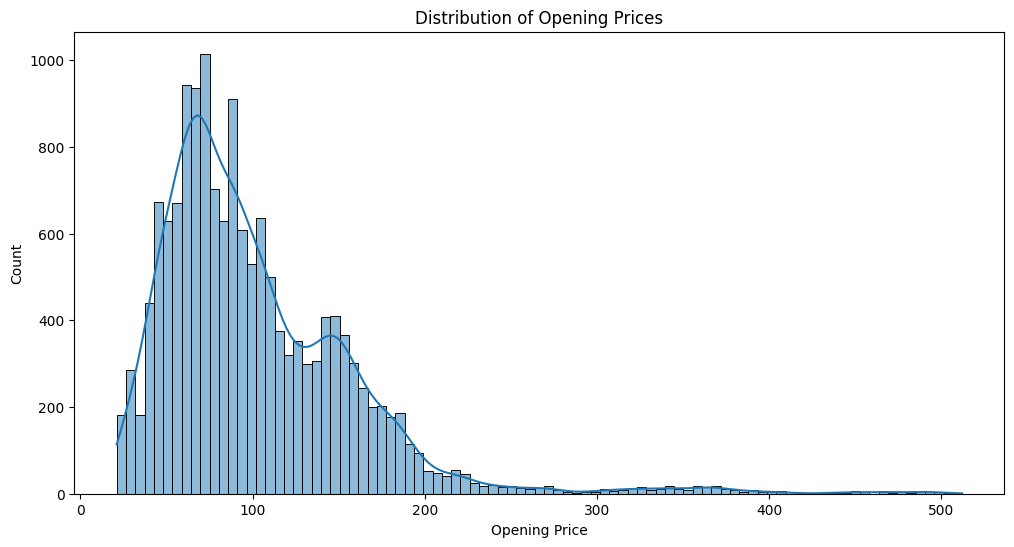

In [21]:
plt.figure(figsize=(12,6))
sns.histplot(stk_prices_indicators['open'], kde=True)
plt.title('Distribution of Opening Prices')
plt.xlabel('Opening Price')

<Axes: xlabel='open'>

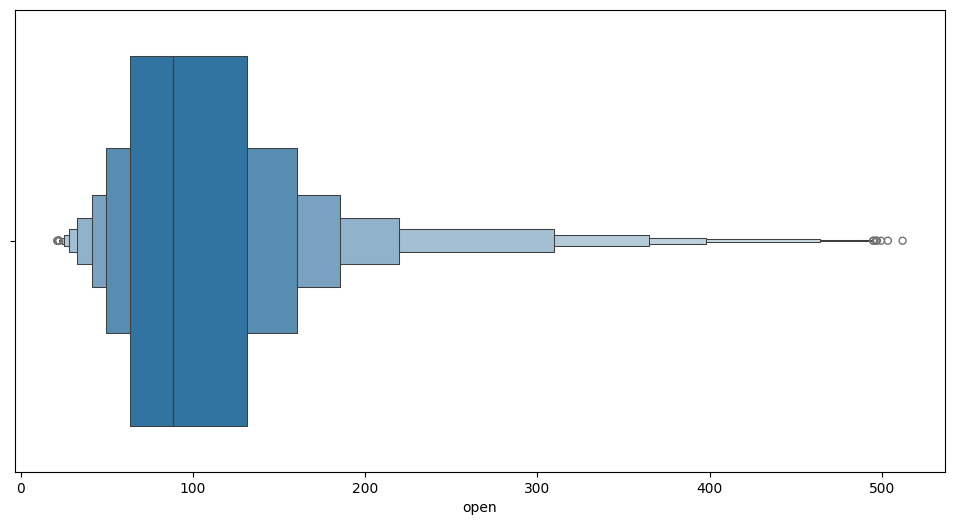

In [23]:
#Boxplot of opening prices
plt.figure(figsize=(12,6))
sns.boxenplot(data=stk_prices_indicators['open'], orient='h')

##### The data appears quite skewed to the right, with a long tail on the right side. This indicates that there are a few instances of very high opening prices compared to the majority of the data. There are visible outliers, fluctuations are however expected with stock prices data, removing them could destroy important signals and blind model to volatility. 

In [26]:
print(stk_prices_indicators['open'].isnull().sum())

0


##### There are no missing values in the data. 

In [36]:
stk_prices_indicators.groupby(['ticker','Year'])['open'] \
    .agg(mean_open='mean', median_open='median') \
    .sort_values(by='mean_open', ascending=False)

mean_open  median_open
ticker Year                         
STK001 2023  366.094078      360.990
STK003 2022  224.110269      207.230
       2023  186.781412      184.430
       2021  184.756000      170.600
STK004 2021  165.772500      164.465
STK001 2021  164.756115      155.425
STK002 2021  160.979154      158.690
STK001 2022  158.683923      160.320
STK011 2023  155.833608      153.720
STK009 2023  150.780275      135.640
STK008 2023  141.004588      144.180
STK012 2023  140.369961      139.310
STK010 2023  139.639373      135.920
STK014 2023  135.956875      125.120
STK011 2022  135.237577      129.135
       2021  130.672385      130.220
STK002 2023  128.845255      125.910
STK012 2022  126.538154      125.260
STK004 2022  126.307615      103.575
STK010 2022  125.577538      113.580
STK004 2023  119.708667      109.210
STK012 2021  116.492077      117.955
STK009 2022  105.122231      104.935
STK013 2023  103.237843      103.960
STK010 2021  101.776038      105.195
STK002 2022   99.662346       97.380
STK008 2022   98.952808      104.120
STK006 2023   97.711882       94.440
STK005 2023   93.641255       90.550
STK008 2021   87.471154       87.990
STK005 2021   86.438538       87.165
STK013 2022   82.441538       85.055
STK018 2021   81.750923       81.025
STK019 2021   81.373346       84.055
STK020 2021   79.122692       78.880
STK006 2021   78.249385       81.850
STK009 2021   76.316346       75.685
STK005 2022   71.012654       72.640
STK014 2022   70.845077       64.265
       2021   69.444346       68.565
STK007 2021   69.238962       71.120
STK006 2022   69.143077       65.910
STK017 2021   67.244962       69.015
STK007 2023   67.116275       66.790
STK013 2021   67.016308       66.565
STK015 2021   66.634385       68.505
STK017 2023   64.324902       57.300
STK016 2021   63.124731       66.650
STK018 2023   57.488235       57.480
STK007 2022   56.632654       57.260
STK020 2023   56.118941       53.630
STK018 2022   51.674346       48.235
STK017 2022   50.337615       47.110
STK016 2022   49.205615       49.115
       2023   47.571490       47.130
STK019 2022   46.517154       35.210
STK020 2022   46.419154       43.615
STK015 2023   43.732275       42.490
       2022   32.260038       30.905
STK019 2023   28.296824       27.530

##### Ticker 01 has averagely had the highest opening prices across all 3 years.Ticker 03 however has had the highest and most stable high average across the all the tickers and the 3 years. 

In [38]:
stk_prices_indicators['high'].describe()

count    15502.000000
mean       104.210076
std         59.610521
min         22.080000
25%         64.432500
50%         90.090000
75%        132.977500
max        516.020000
Name: high, dtype: float64

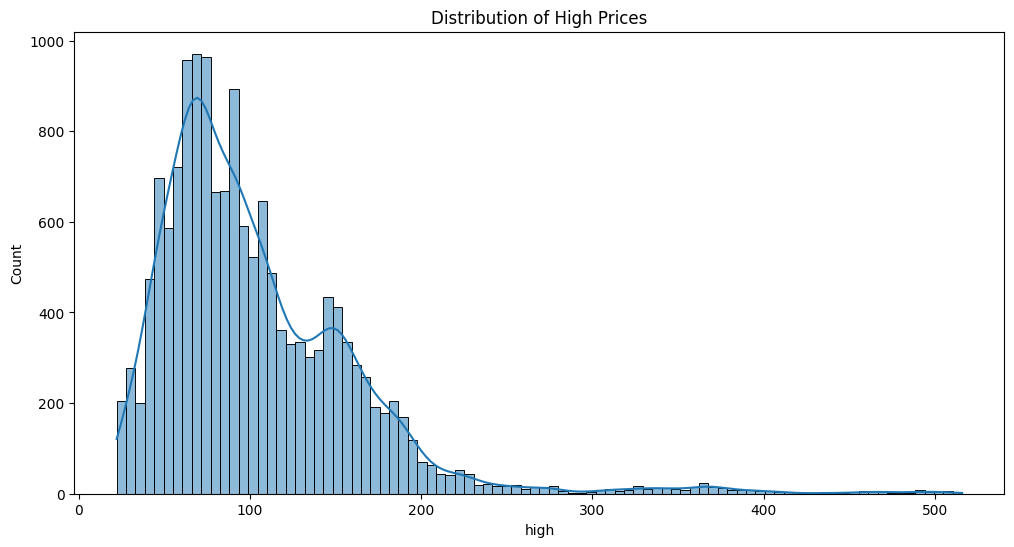

In [40]:
plt.figure(figsize=(12,6))
sns.histplot(stk_prices_indicators['high'], kde=True)
plt.title('Distribution of High Prices');

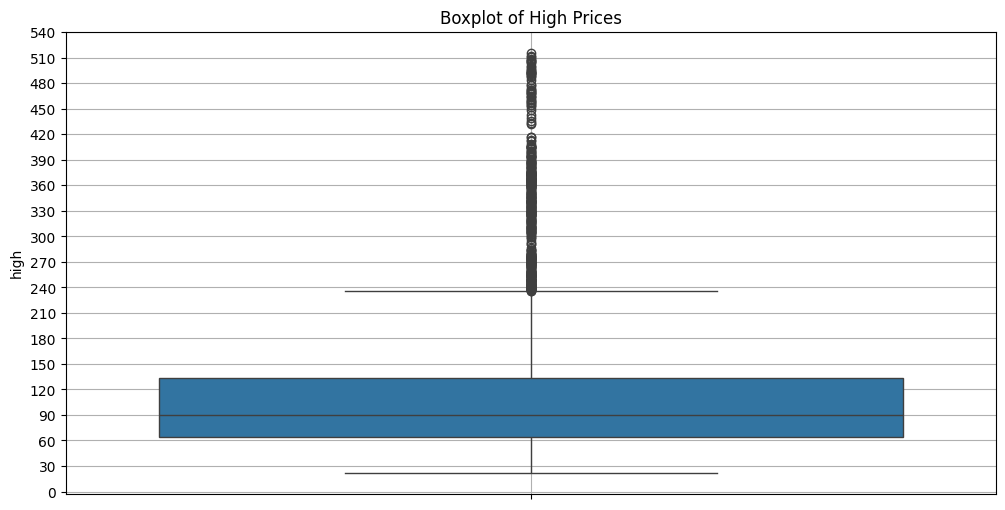

In [24]:
plt.figure(figsize=(12,6))
sns.boxplot(stk_prices_indicators['high'])
plt.title('Boxplot of High Prices')
plt.yticks(range(0,550,30))
plt.grid();

##### The data appears quite skewed to the right, with a long tail on the right side. The also appears bimodal.The average high price is £90 with outliers noted above £240. 

In [42]:
print(stk_prices_indicators['high'].isnull().sum())

0


##### There are no missing values in the high price data.

In [44]:
stk_prices_indicators.low.describe()

count    15502.000000
mean       100.685710
std         57.519995
min         21.060000
25%         62.235000
50%         87.155000
75%        128.850000
max        497.210000
Name: low, dtype: float64

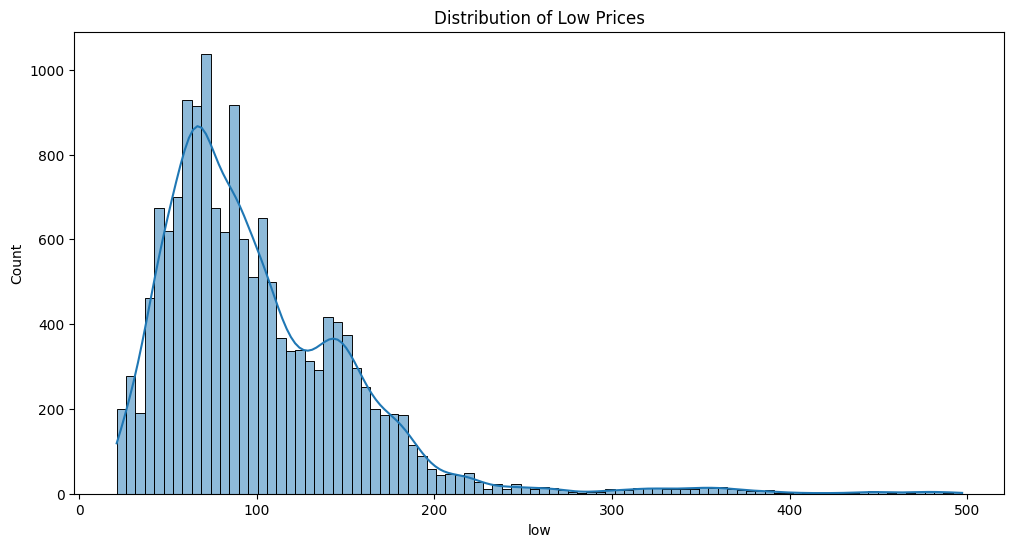

In [45]:
plt.figure(figsize=(12,6))
sns.histplot(stk_prices_indicators['low'], kde=True)
plt.title('Distribution of Low Prices');

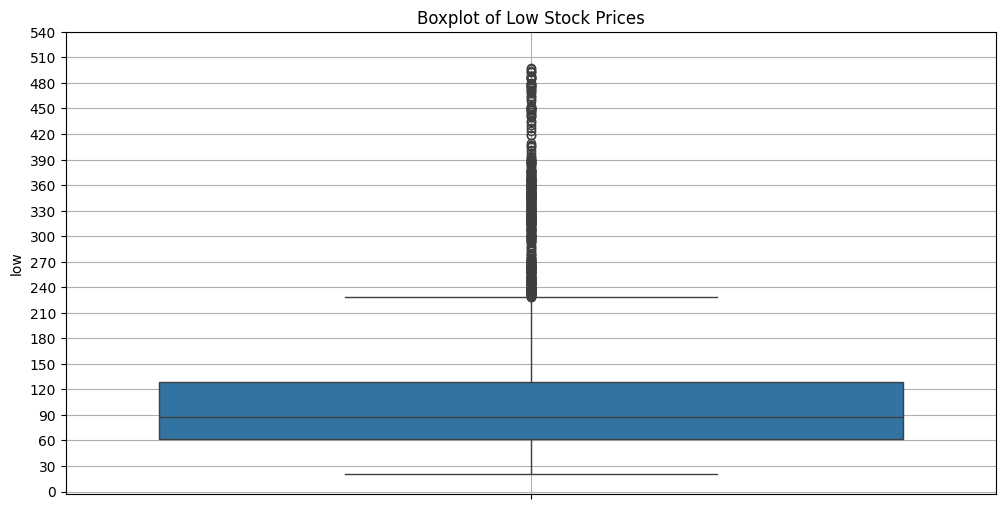

In [21]:
plt.figure(figsize=(12,6))
sns.boxplot(stk_prices_indicators['low'])
plt.yticks(range(0,550,30)) 
plt.grid()
plt.title('Boxplot of Low Stock Prices');

##### The low prices also appears quite skewed to the right, with a long tail on the right side. They also appear bimodal. The majority of the prices also tend to fall below 200 with fewer larger values. There are visible outliers, fluctuations are however expected with stock prices data, removing them could destroy important signals and blind model to volatility.

In [ ]:
stk_prices_indicators['close'].describe()

count    15502.000000
mean       102.447796
std         58.583470
min         21.440000
25%         63.332500
50%         88.650000
75%        130.967500
max        509.110000
Name: close, dtype: float64

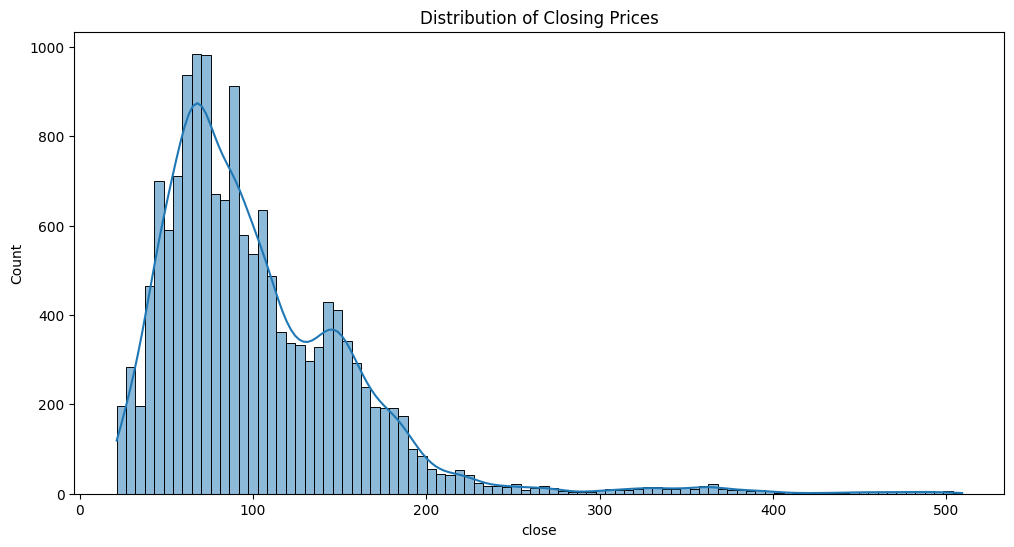

In [48]:
plt.figure(figsize=(12,6))
sns.histplot(stk_prices_indicators['close'], kde=True)
plt.title('Distribution of Closing Prices');

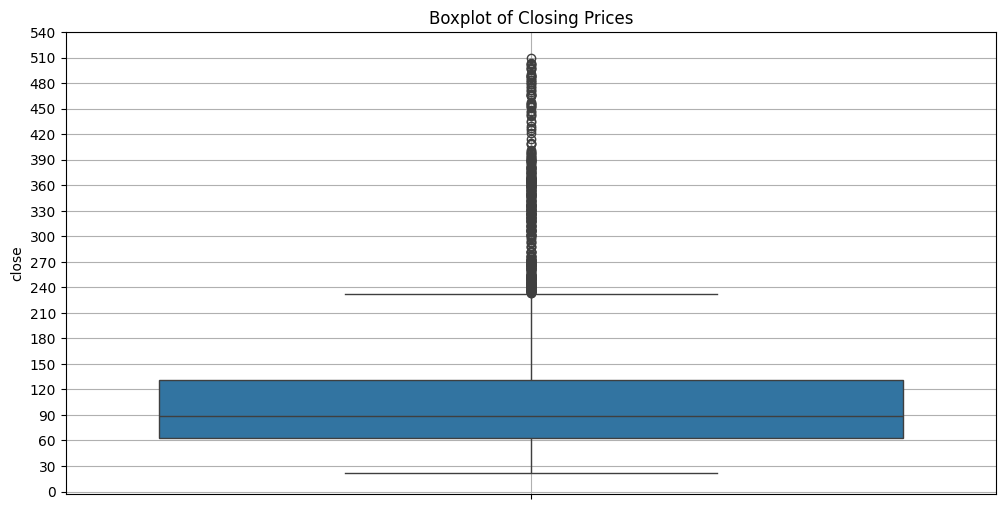

In [16]:
plt.figure(figsize=(12,6))
sns.boxplot(stk_prices_indicators['close'])
plt.yticks(range(0,550,30))
plt.grid()
plt.title('Boxplot of Closing Prices');

##### The dataset for the closing prices is skewed to the right with obvious outliers. The data is also multimodal. There are some evident outliers above 230 with an average closing price of £90.

In [26]:
round(stk_prices_indicators['volume'].describe(),0)

count       15502.0
mean      1255806.0
std        388043.0
min        801893.0
25%       1069136.0
50%       1249854.0
75%       1420747.0
max      13996964.0
Name: volume, dtype: float64

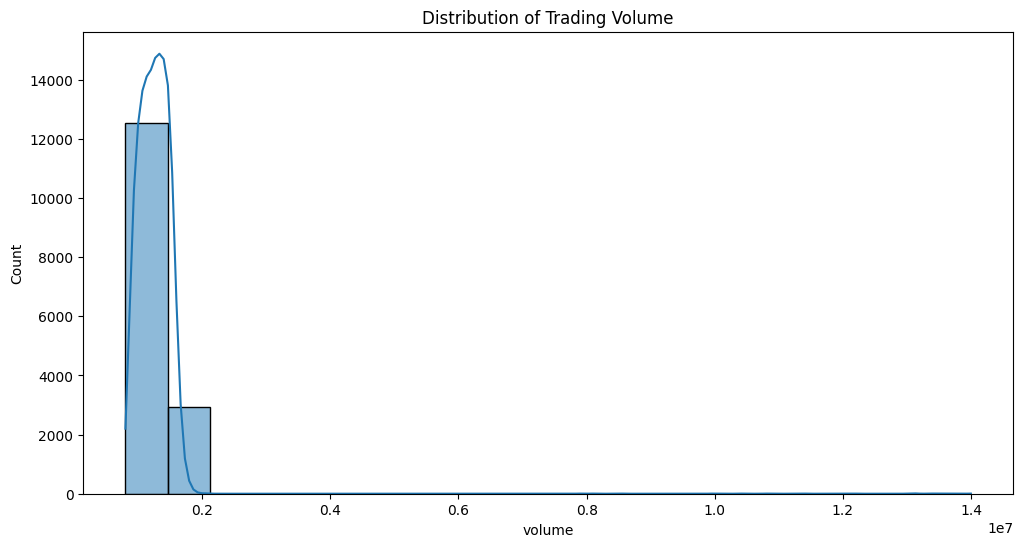

In [ ]:
plt.figure(figsize=(12,6))
sns.histplot(stk_prices_indicators['volume'], ins=20,kde=True)
plt.title('Distribution of Trading Volume');

In [27]:
stk_prices_indicators.columns

Index(['ticker', 'open', 'high', 'low', 'close', 'volume', 'adjusted_close',
       'sma_20', 'sma_50', 'sma_200', 'ema_12', 'ema_26', 'macd',
       'macd_signal', 'macd_histogram', 'rsi_14', 'bb_middle', 'bb_upper',
       'bb_lower', 'bb_width', 'true_range', 'atr_14', 'volume_sma_20',
       'volume_ratio', 'momentum_10', 'momentum_20', 'price_to_sma_50',
       'volatility_20', 'future_return_5d', 'trend_label', 'Year', 'Month',
       'Day', 'mnth_yr'],
      dtype='object')

In [ ]:
stk_prices_indicators['close'].resample('M').mean().plot(figsize=(12,6))

C:\Users\ofori\AppData\Local\Temp\ipykernel_18816\67523363.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


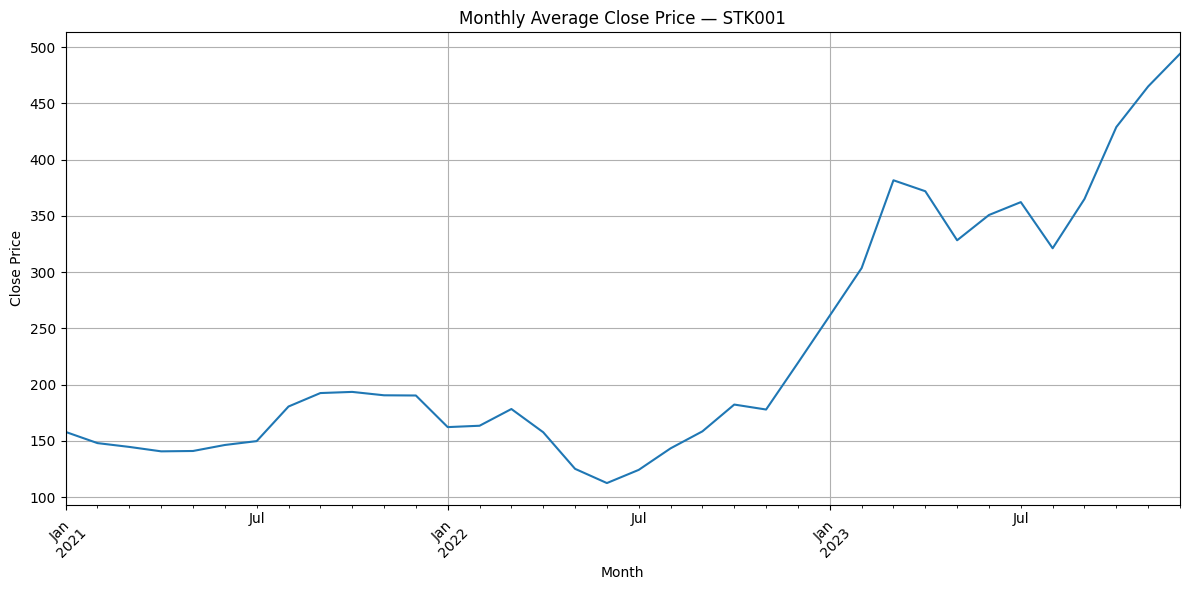

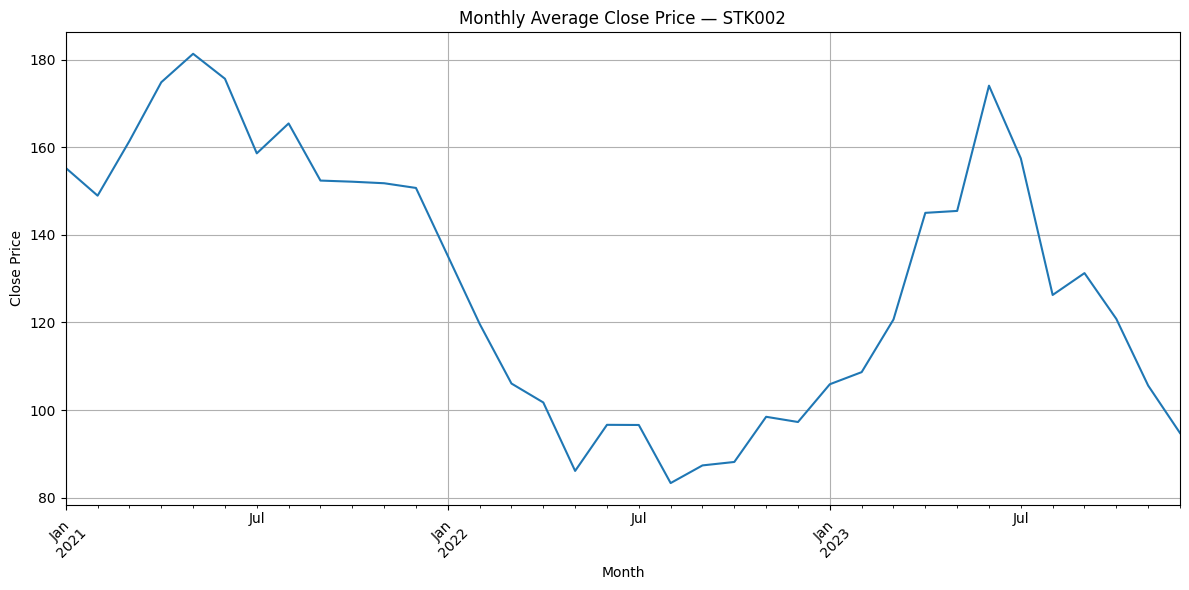

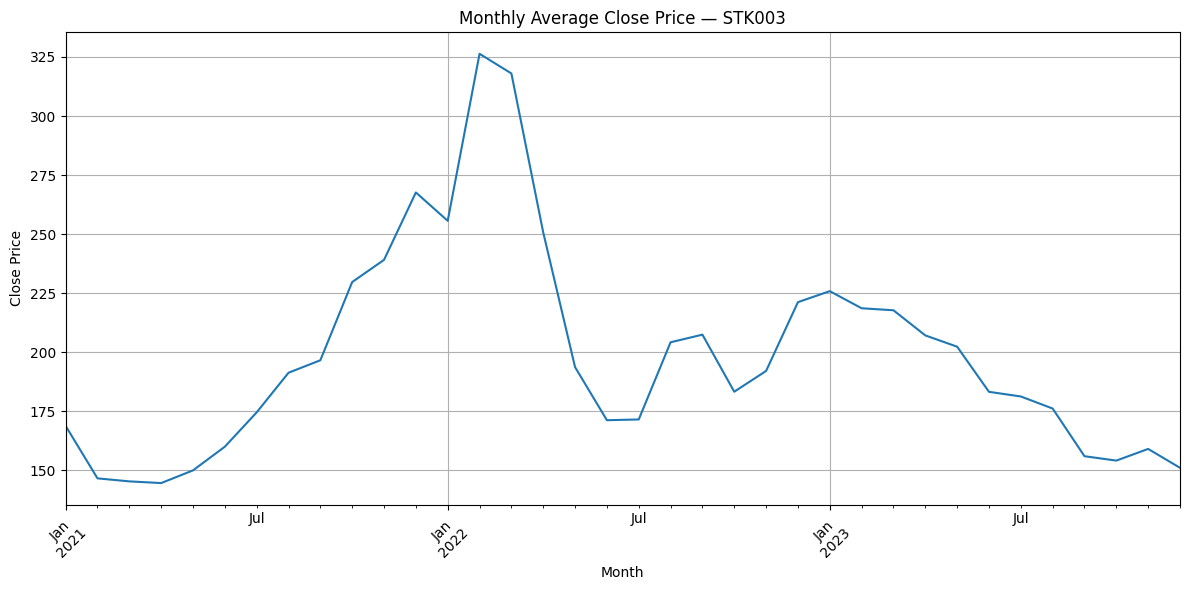

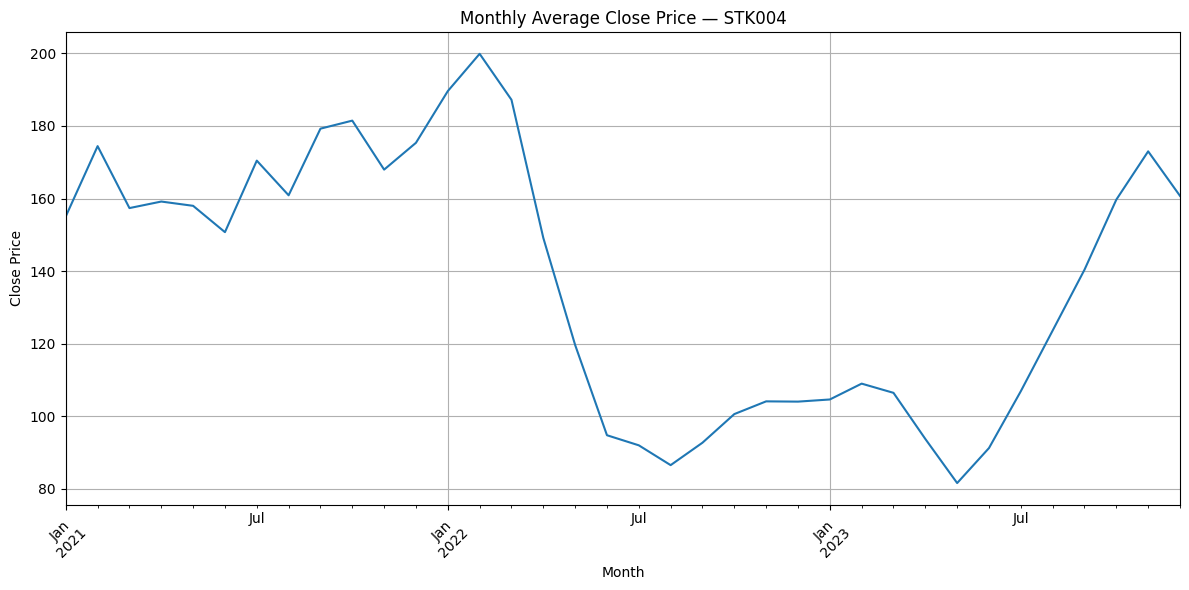

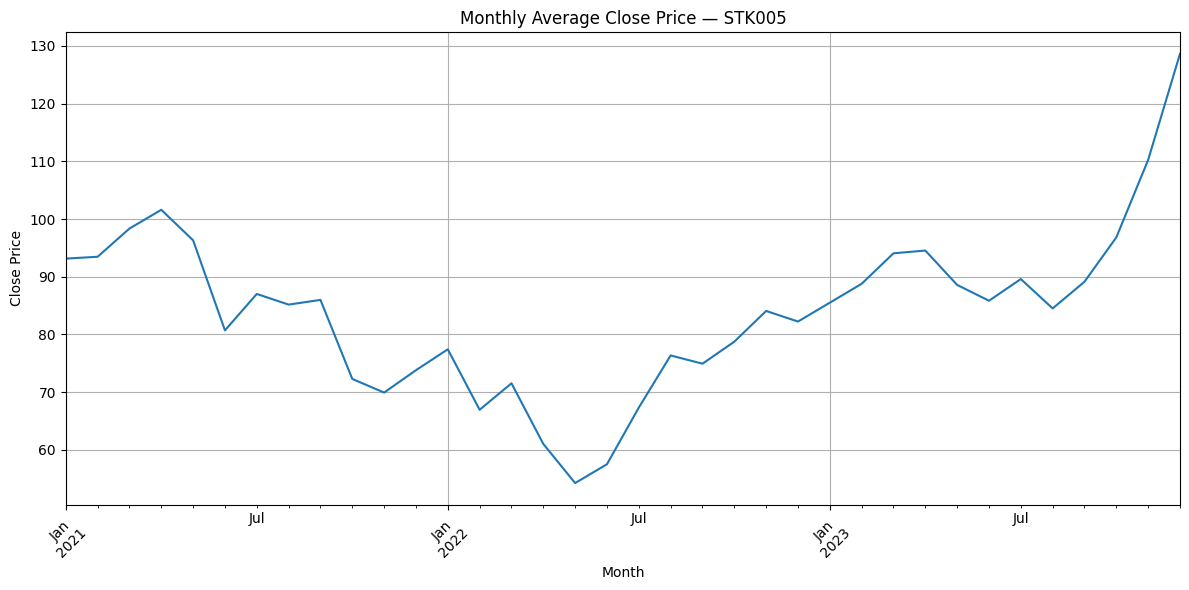

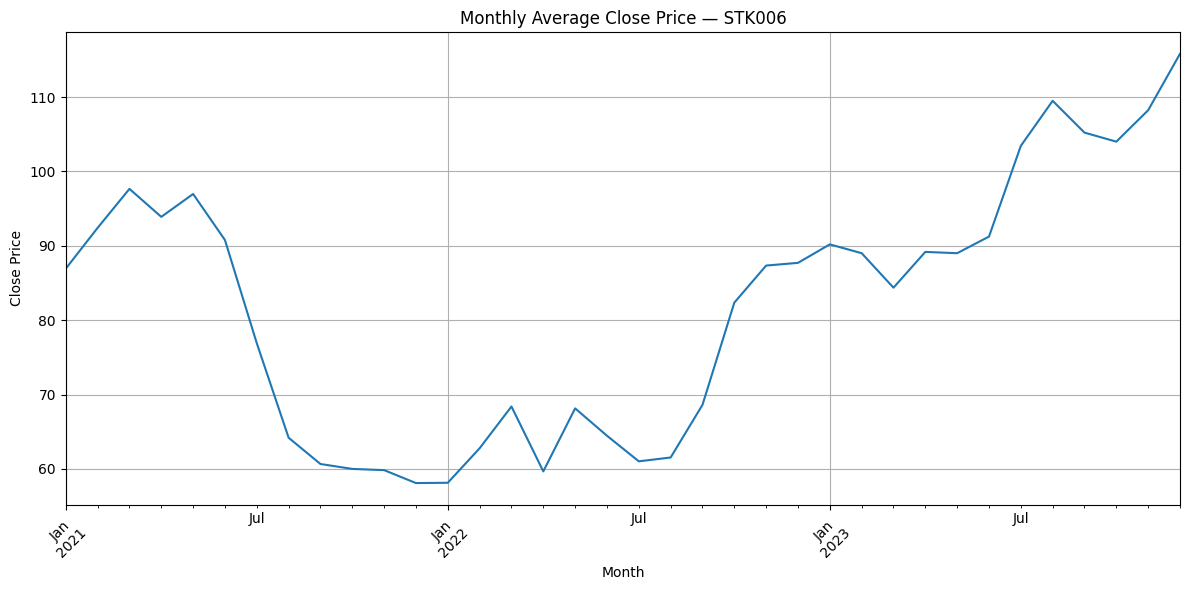

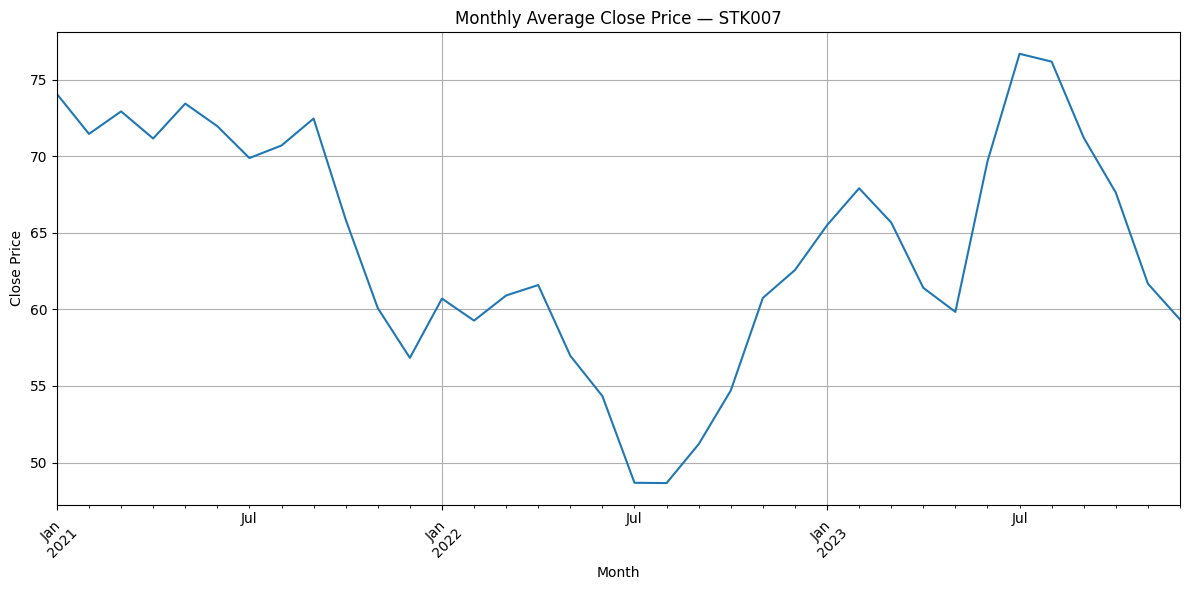

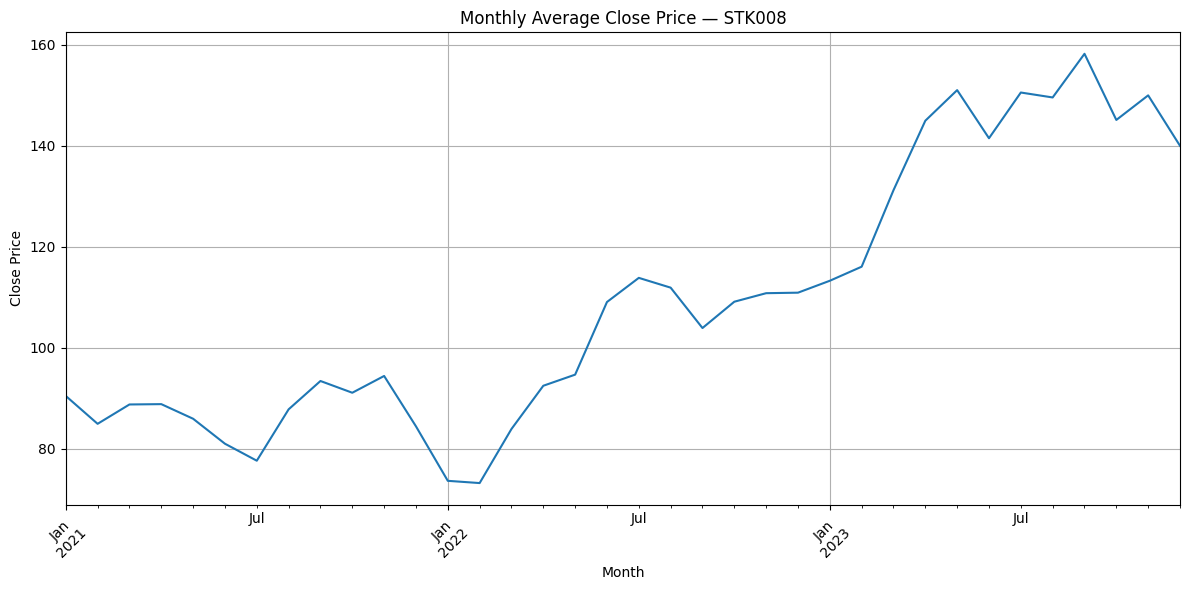

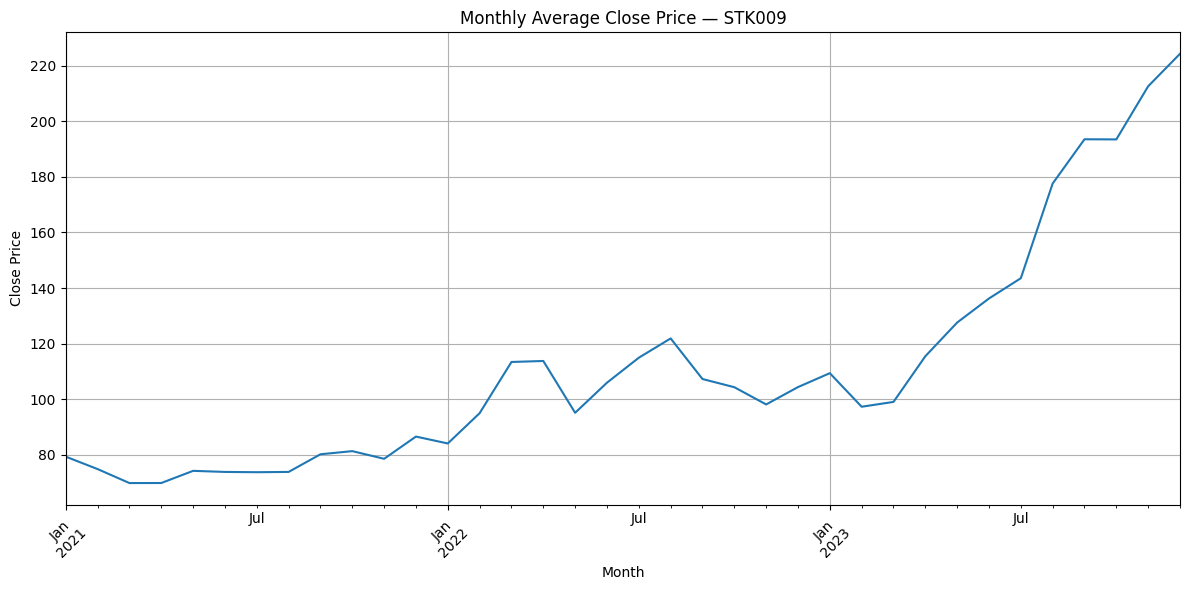

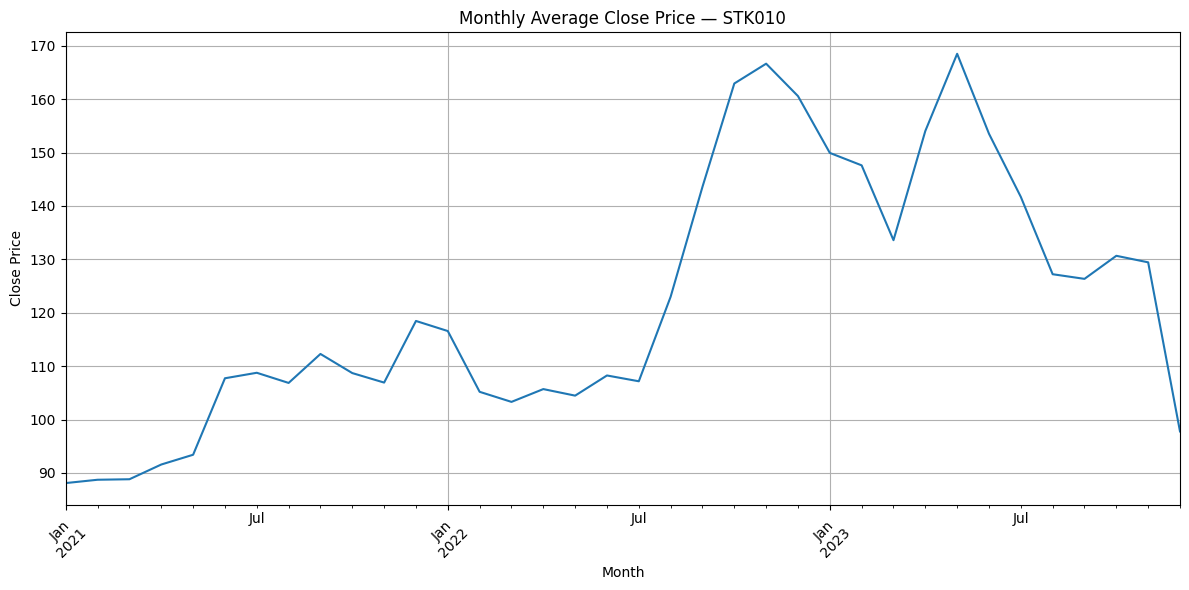

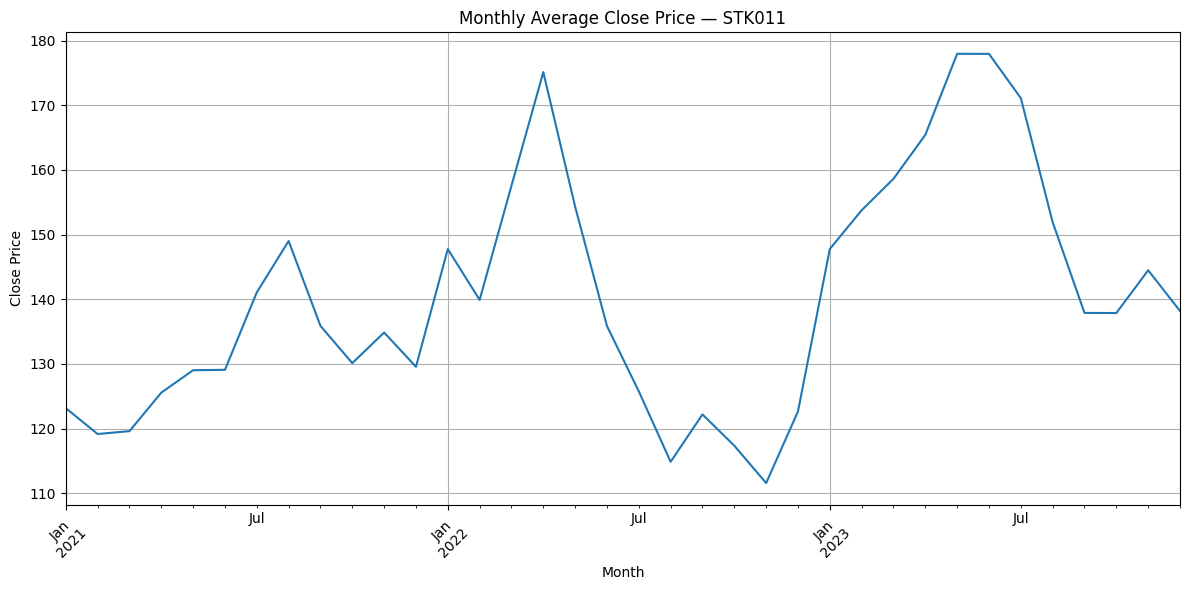

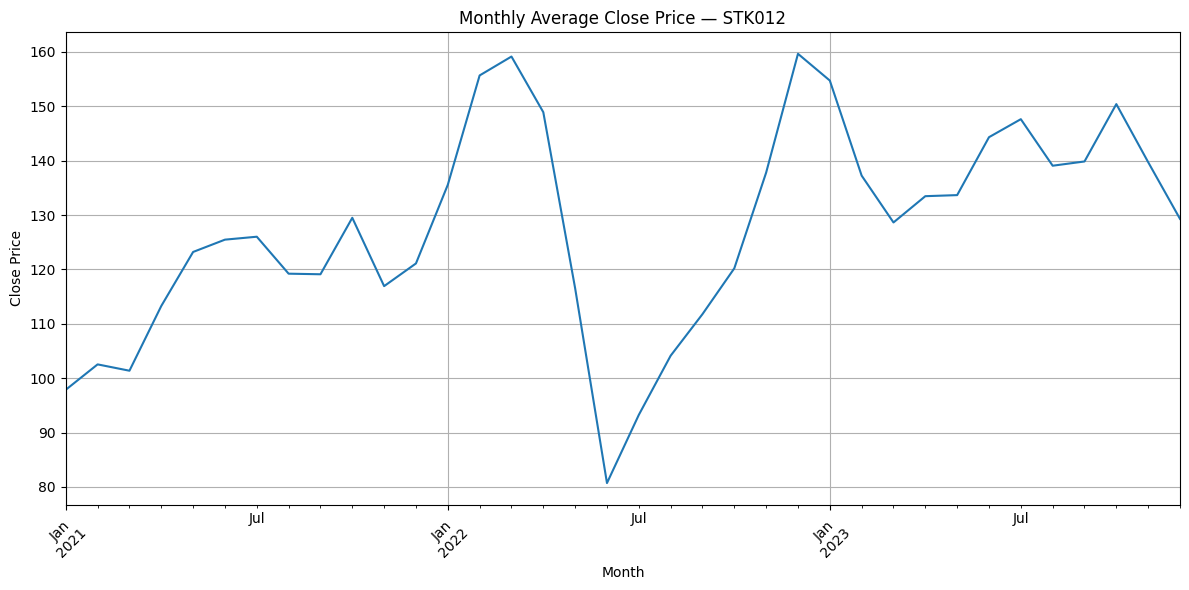

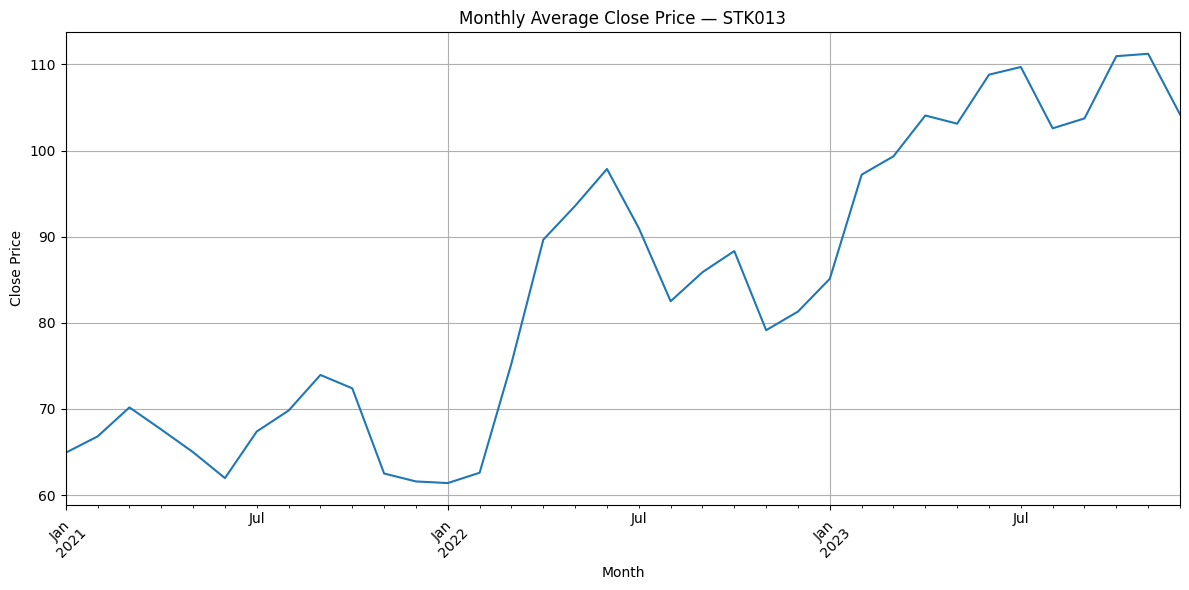

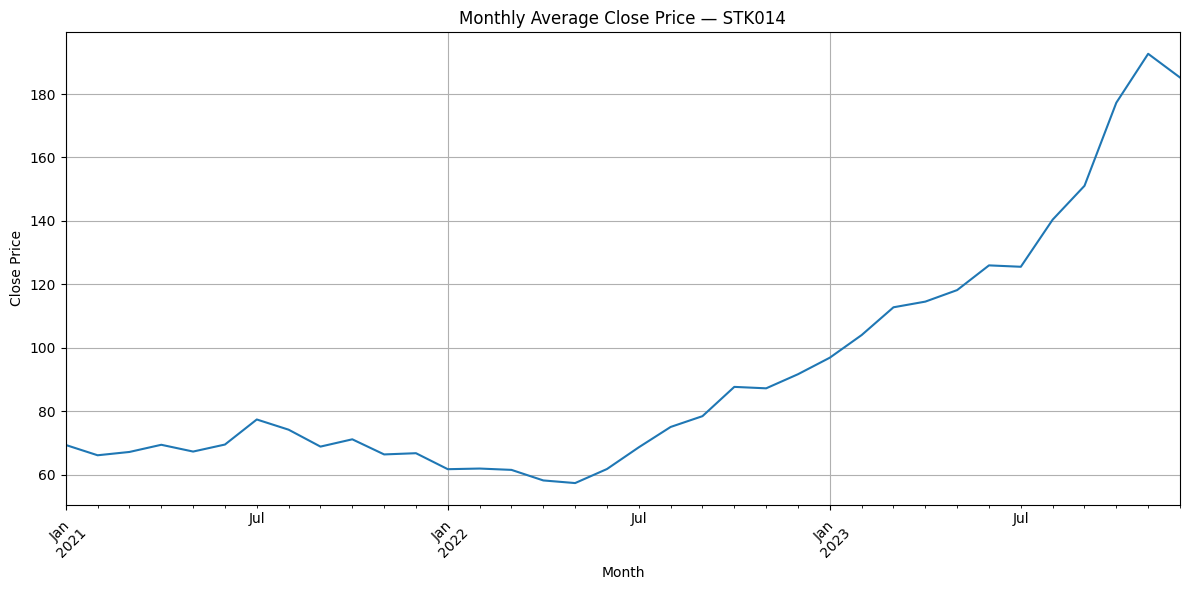

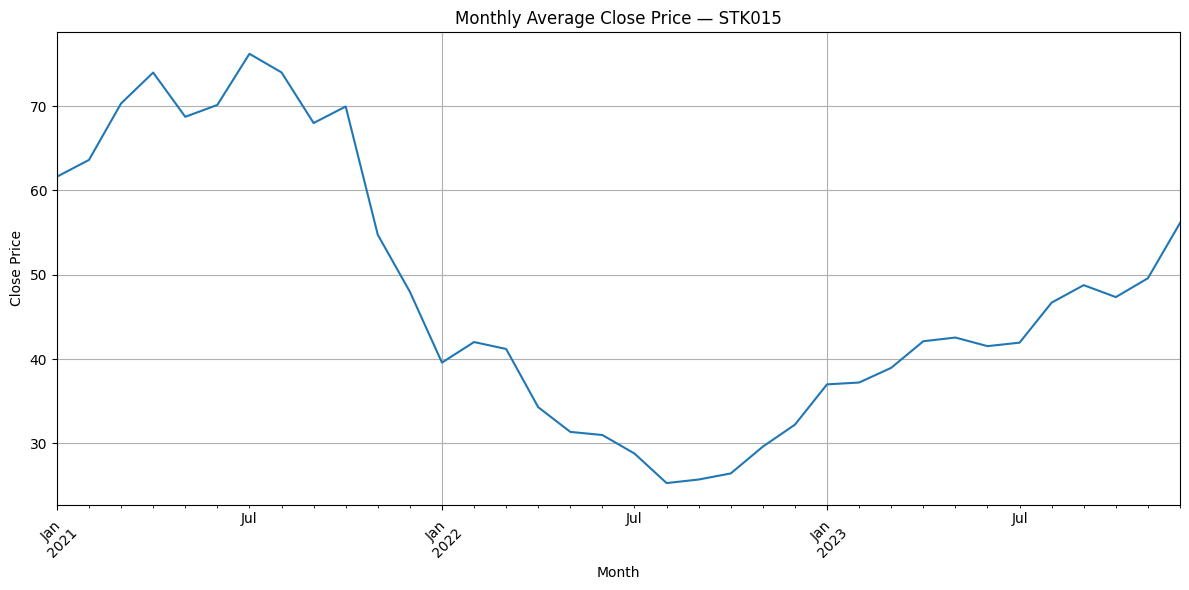

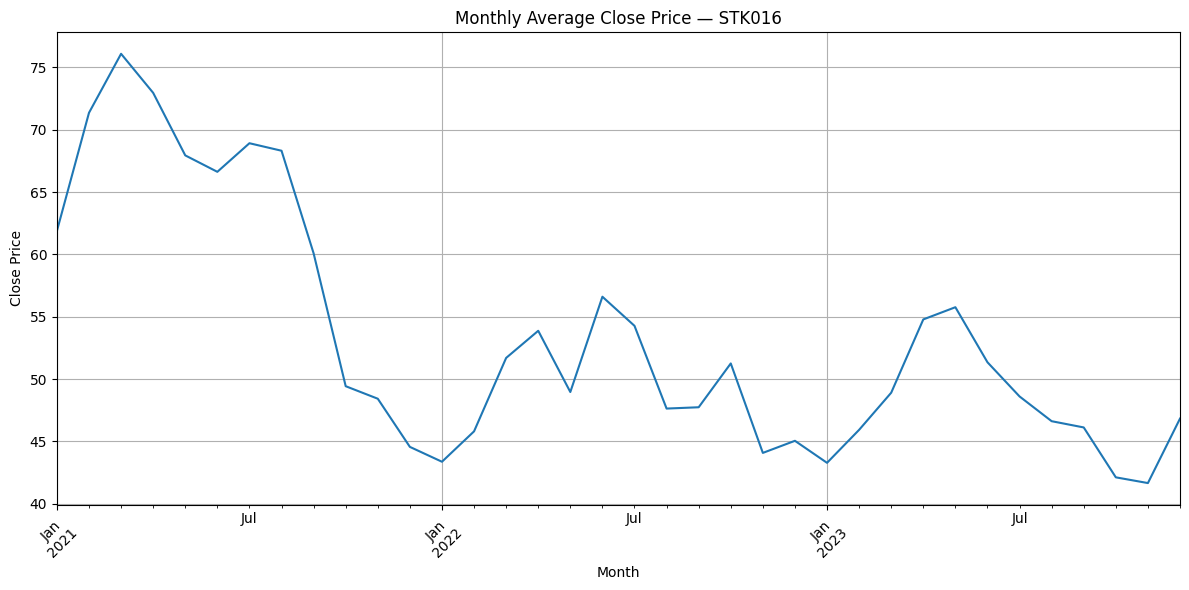

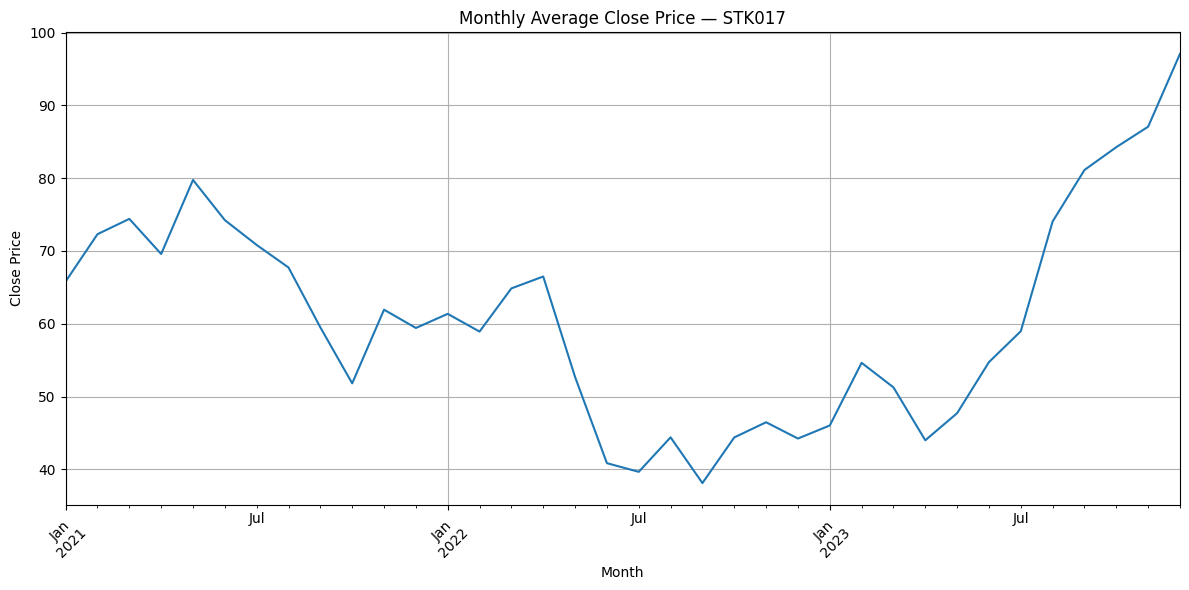

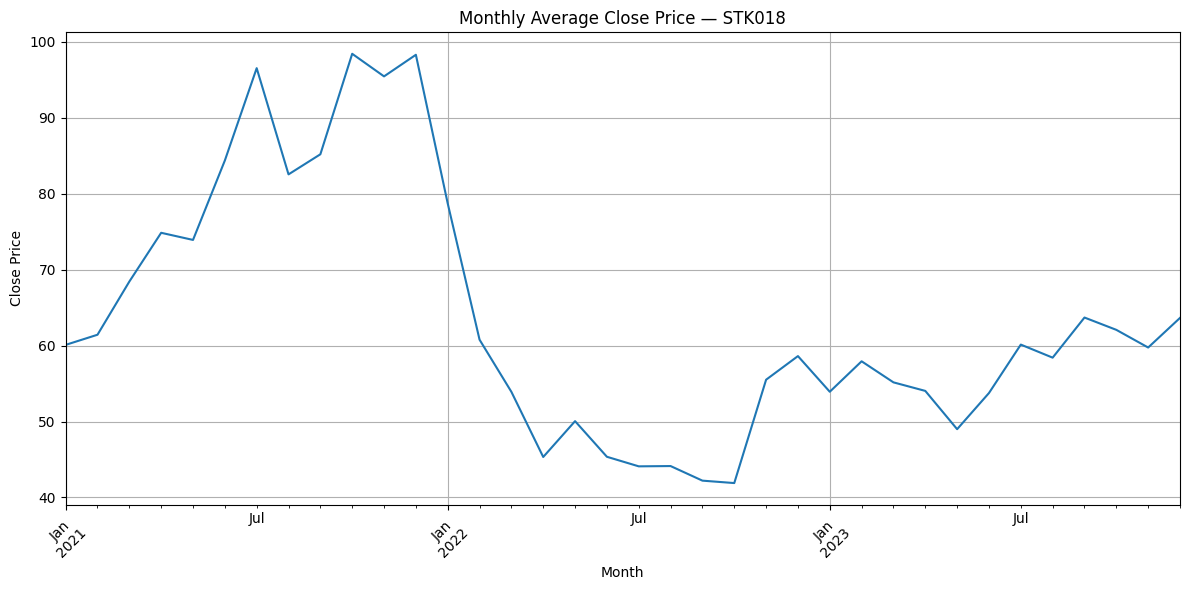

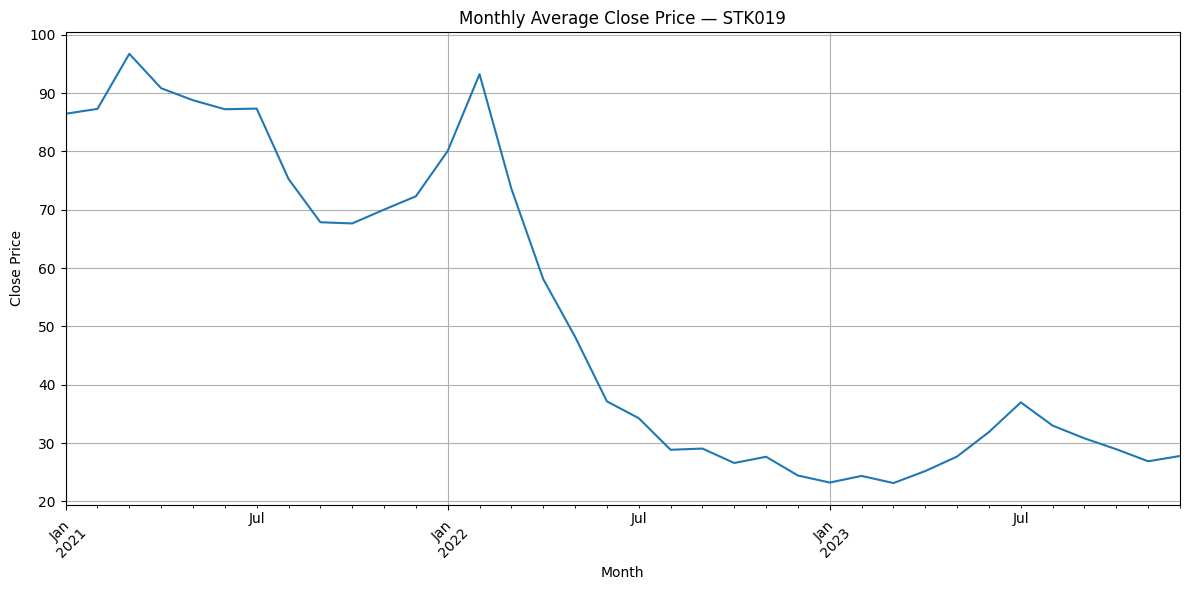

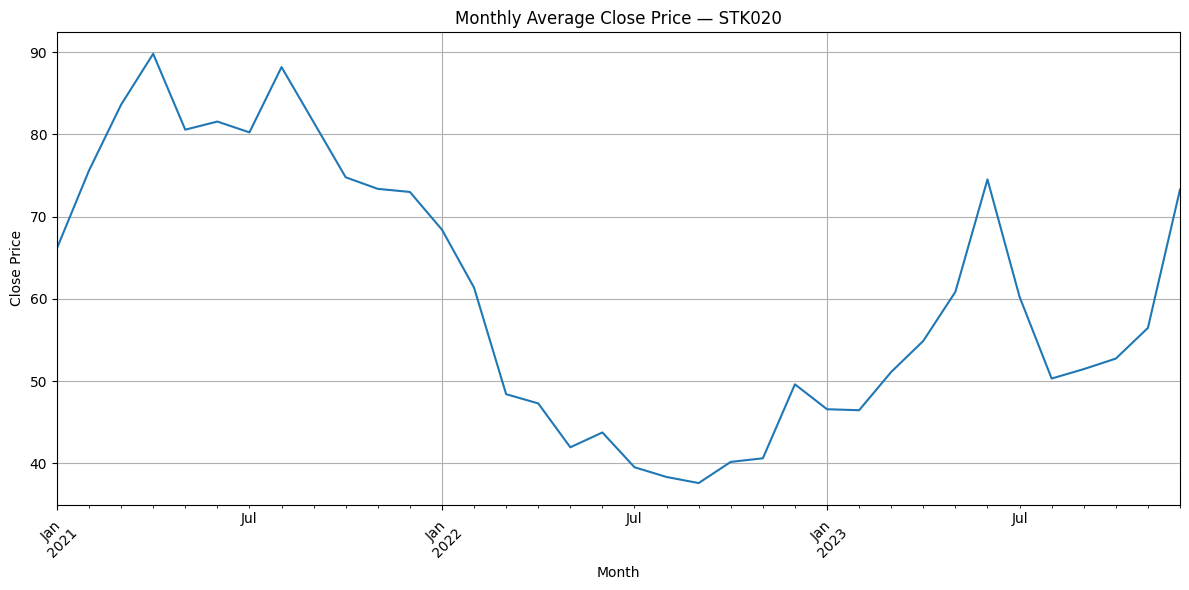

In [ ]:
monthly = (
    stk_prices_indicators
    .set_index("mnth_yr")
    .groupby("ticker")["close"]
    .resample("ME")
    .mean()
)
tickers = stk_prices2["ticker"].unique()

for t in tickers:
    plt.figure(figsize=(12,6))

    # Plot monthly averages
    monthly.loc[t].plot()

    plt.title(f"Monthly Average Close Price — {t}")
    plt.xlabel("Month")
    plt.ylabel("Close Price")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


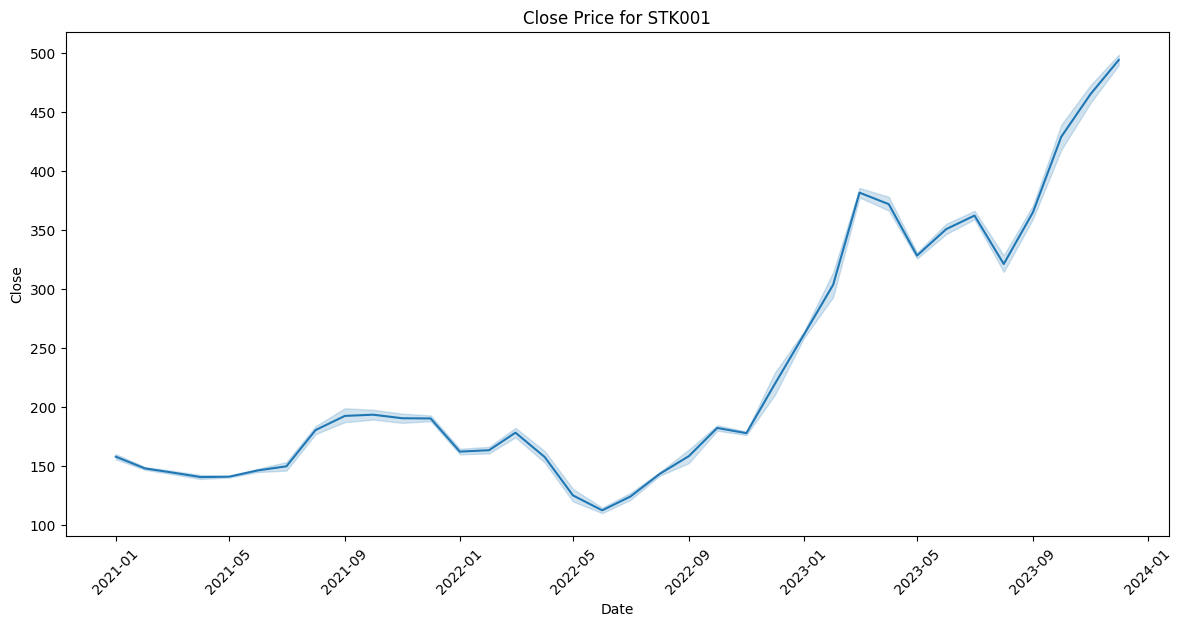

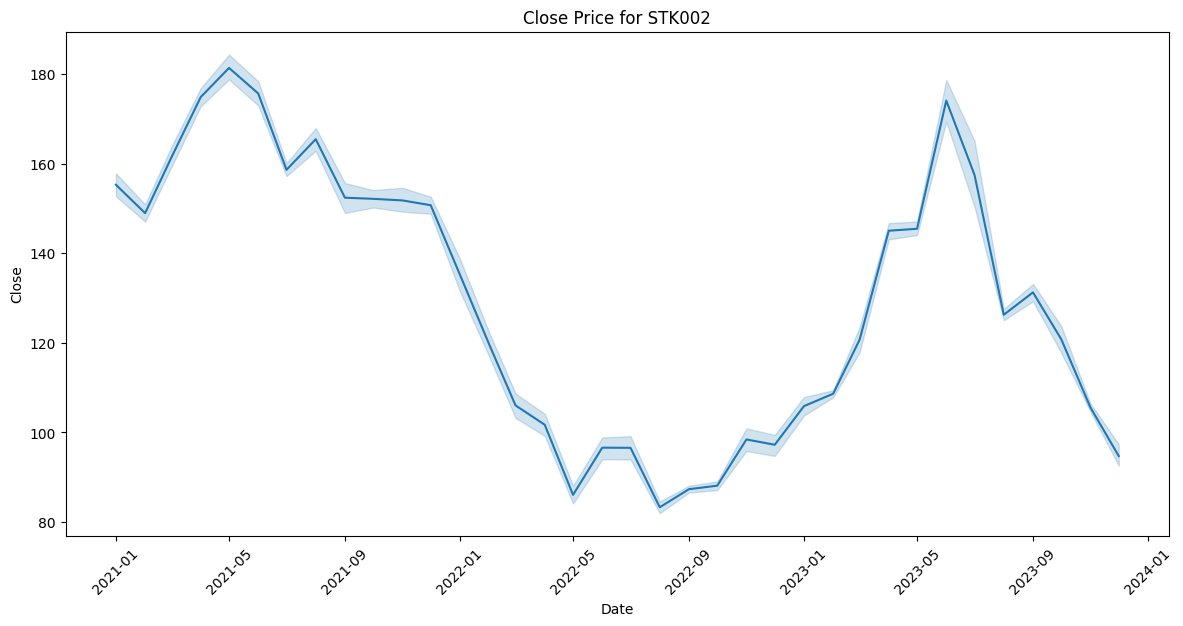

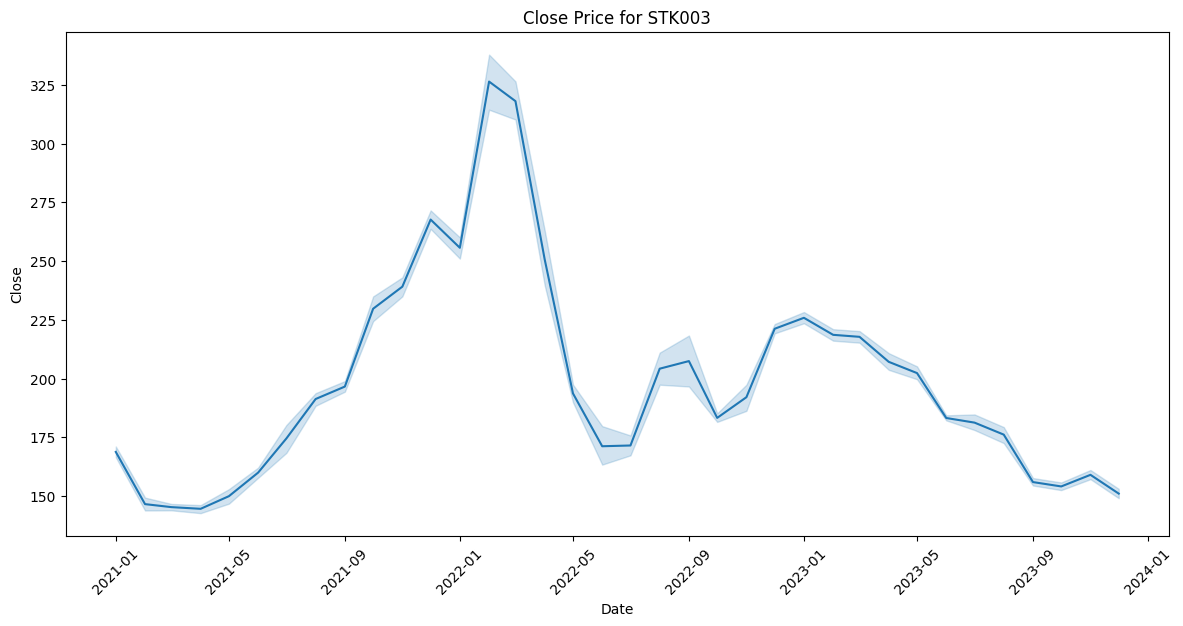

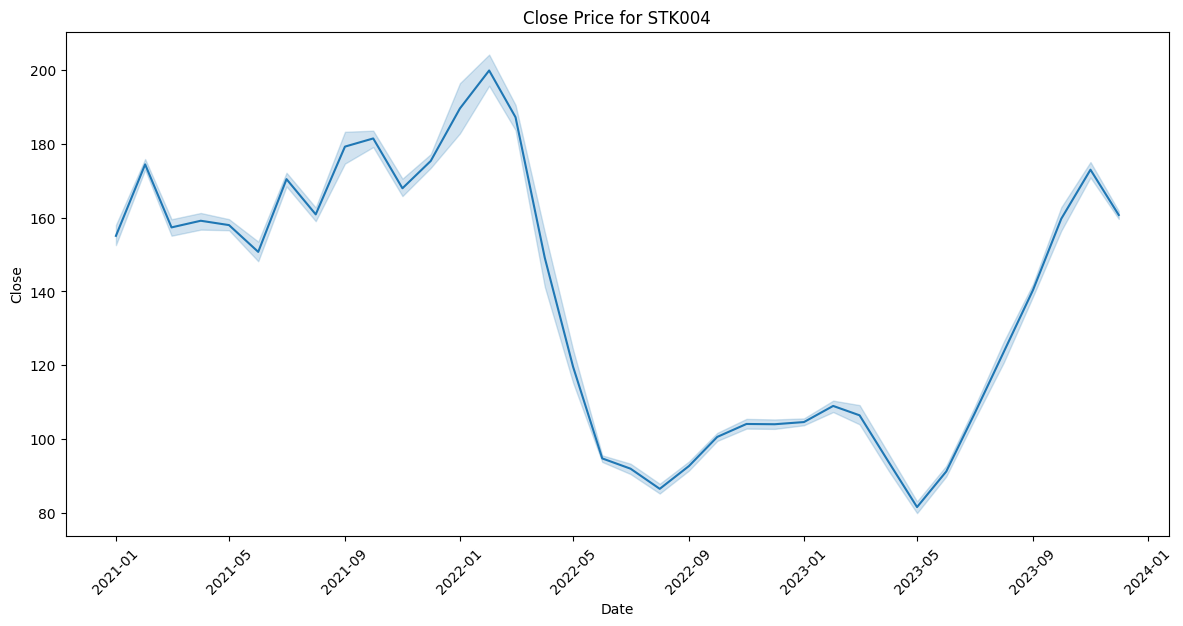

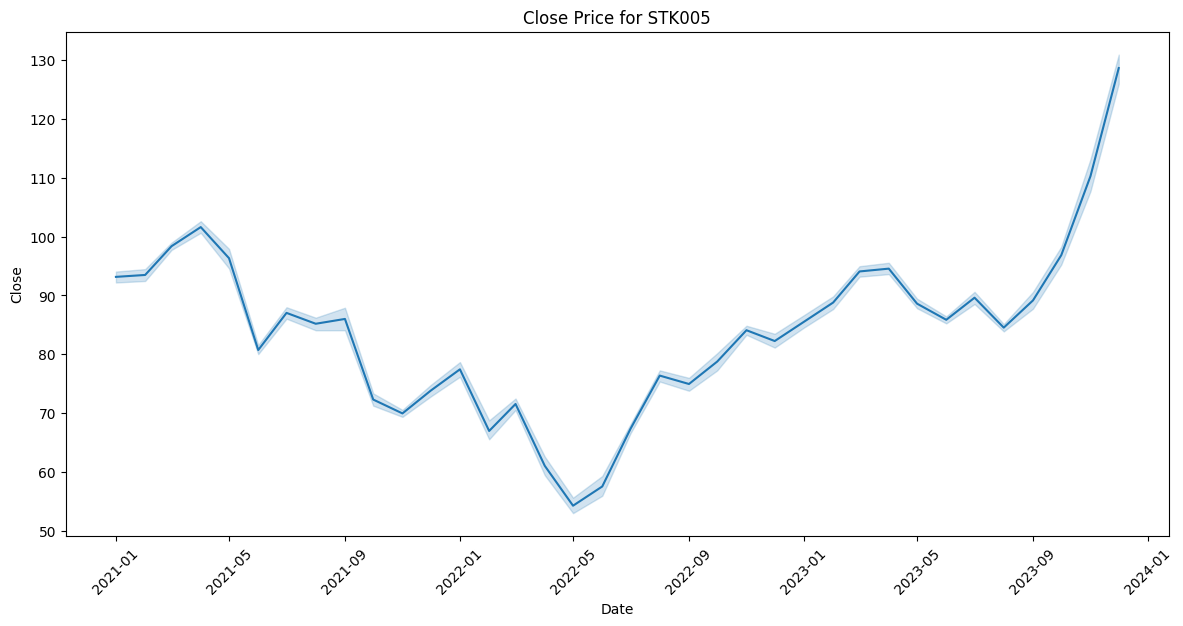

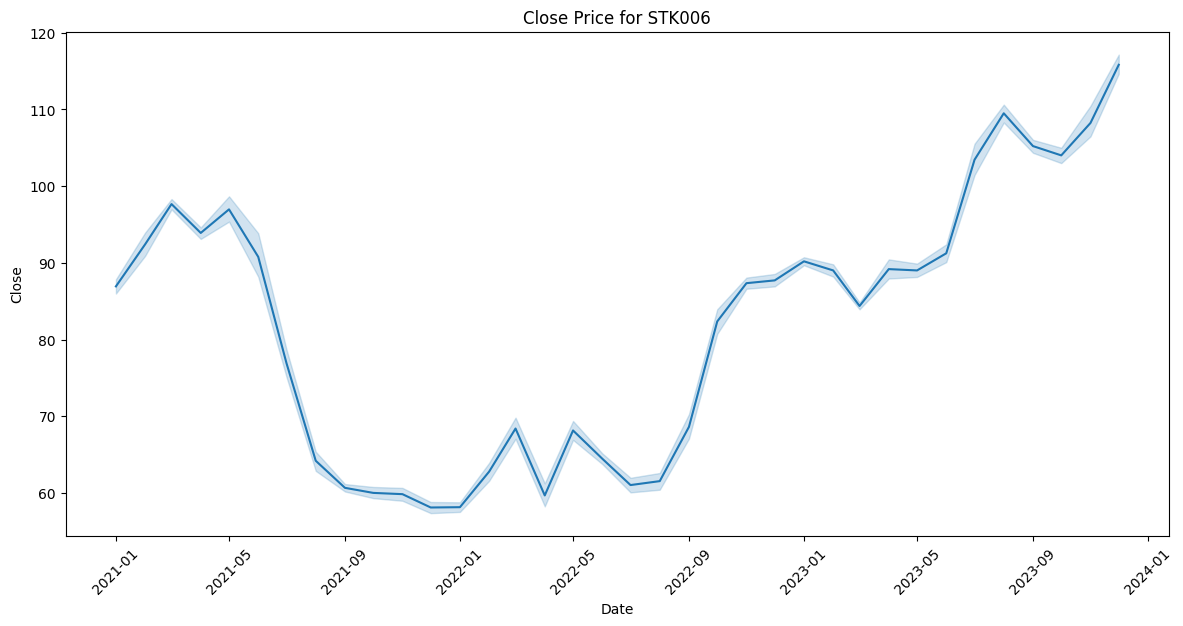

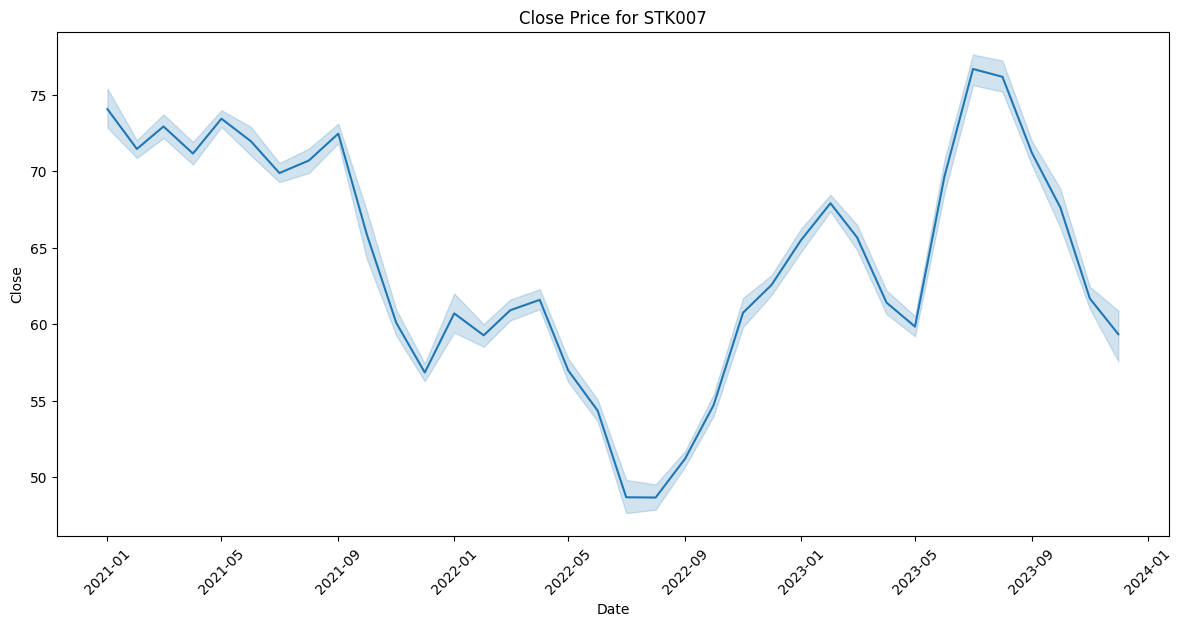

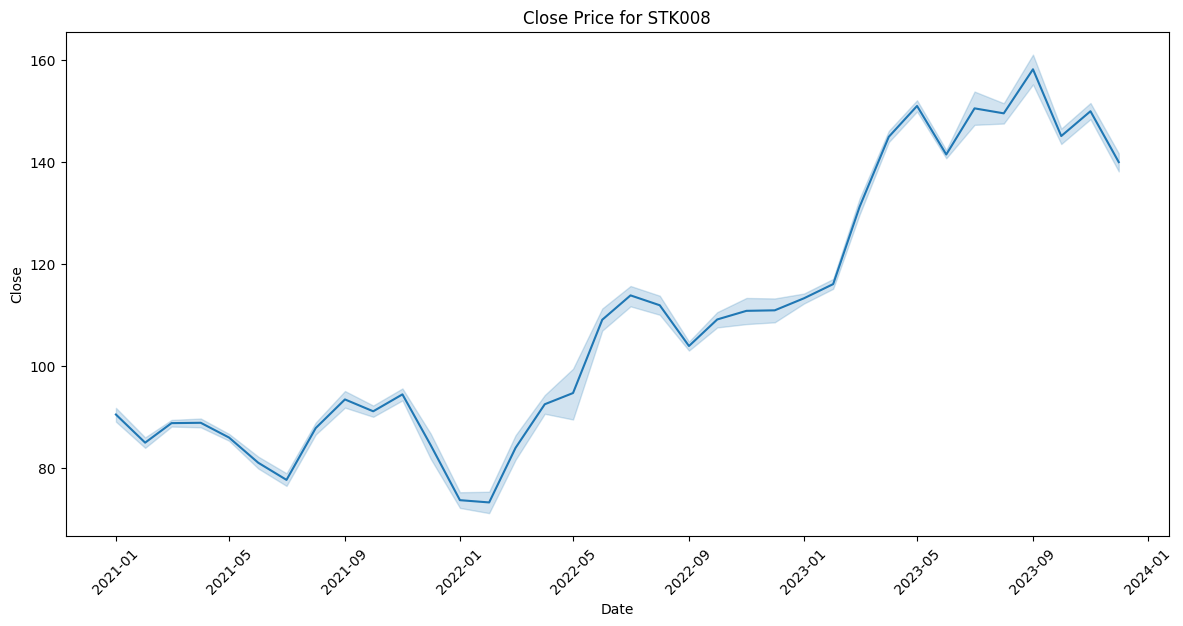

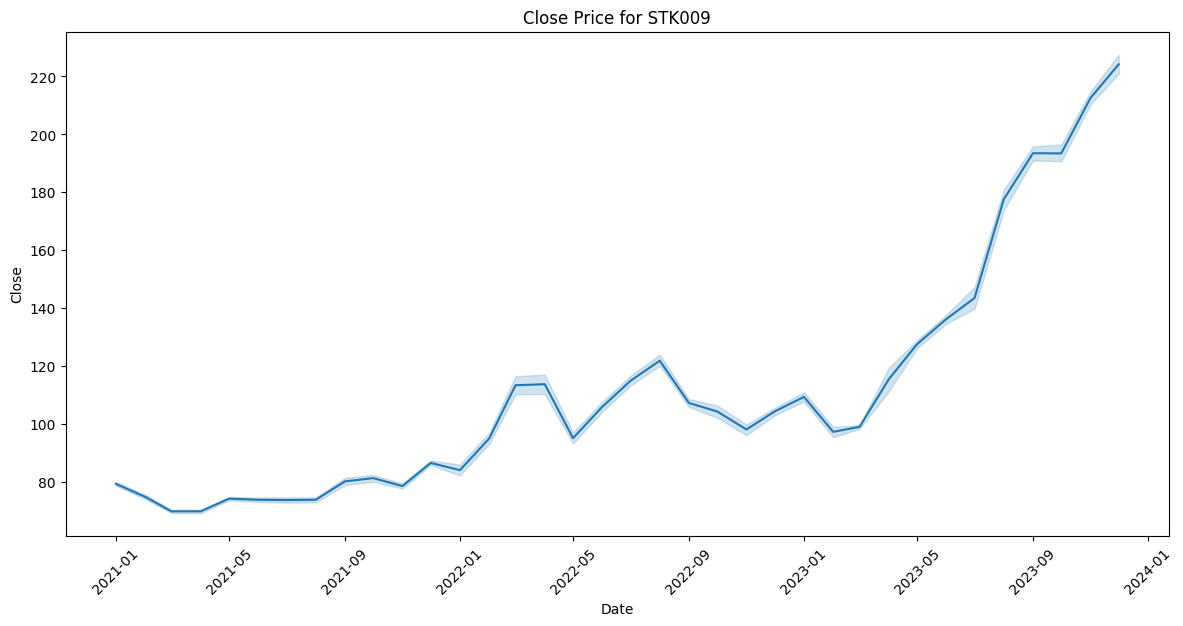

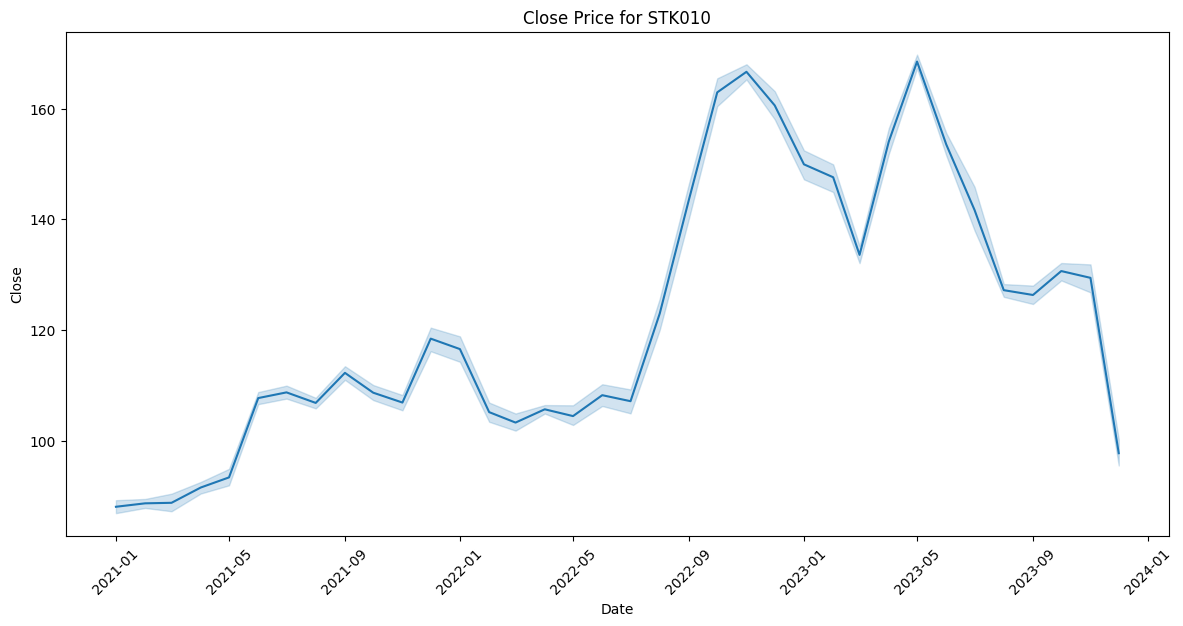

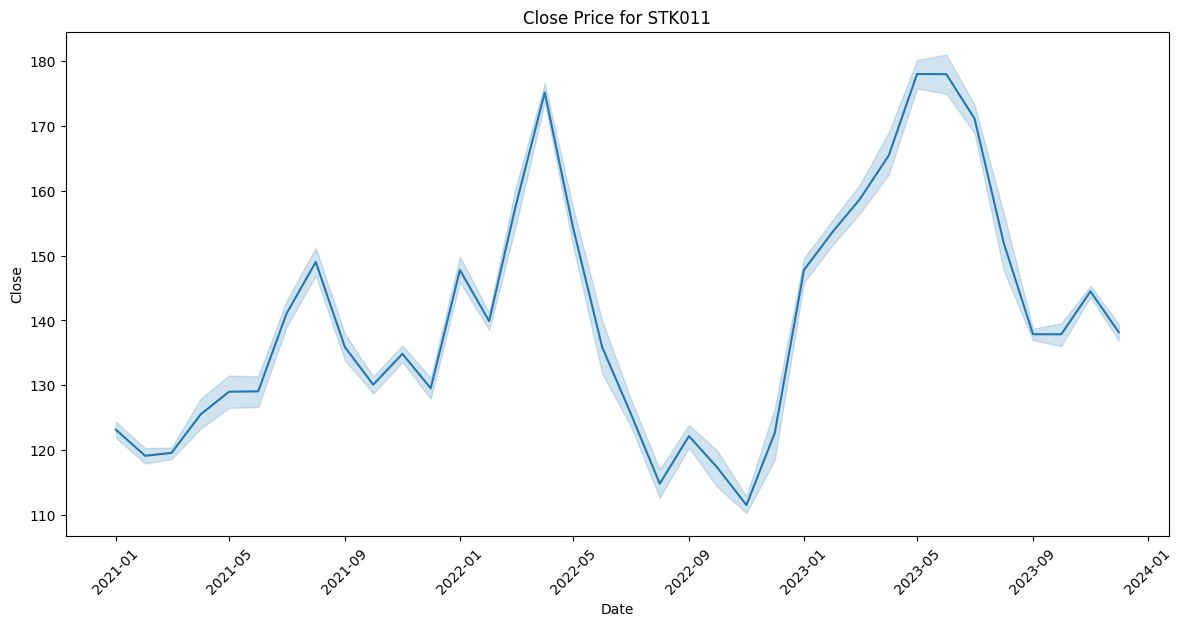

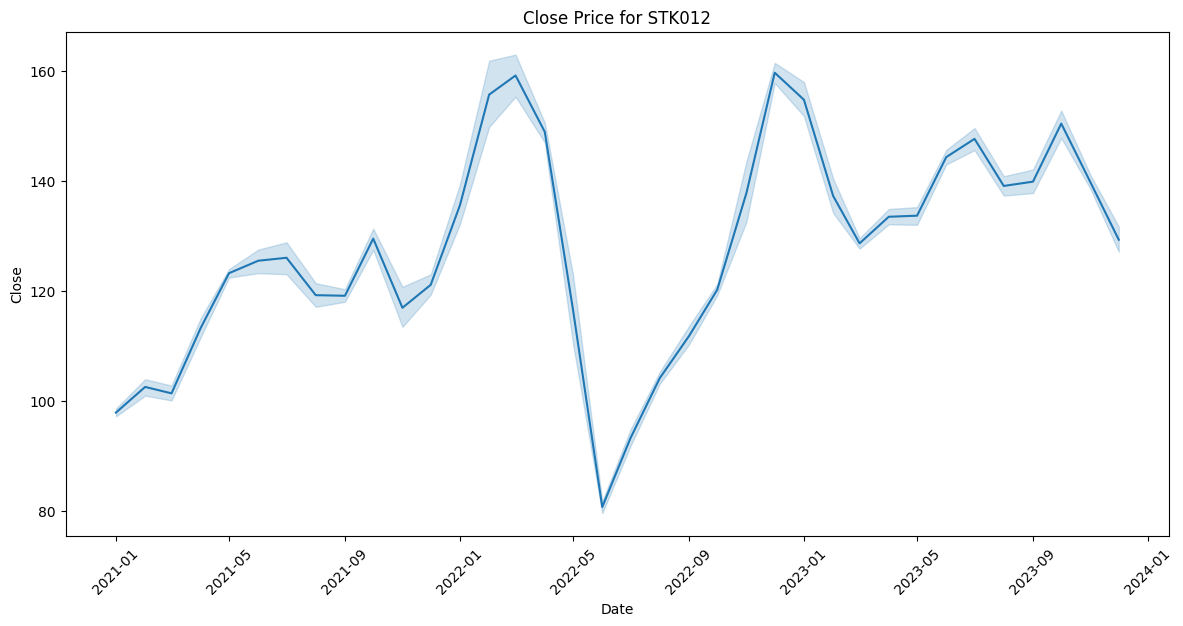

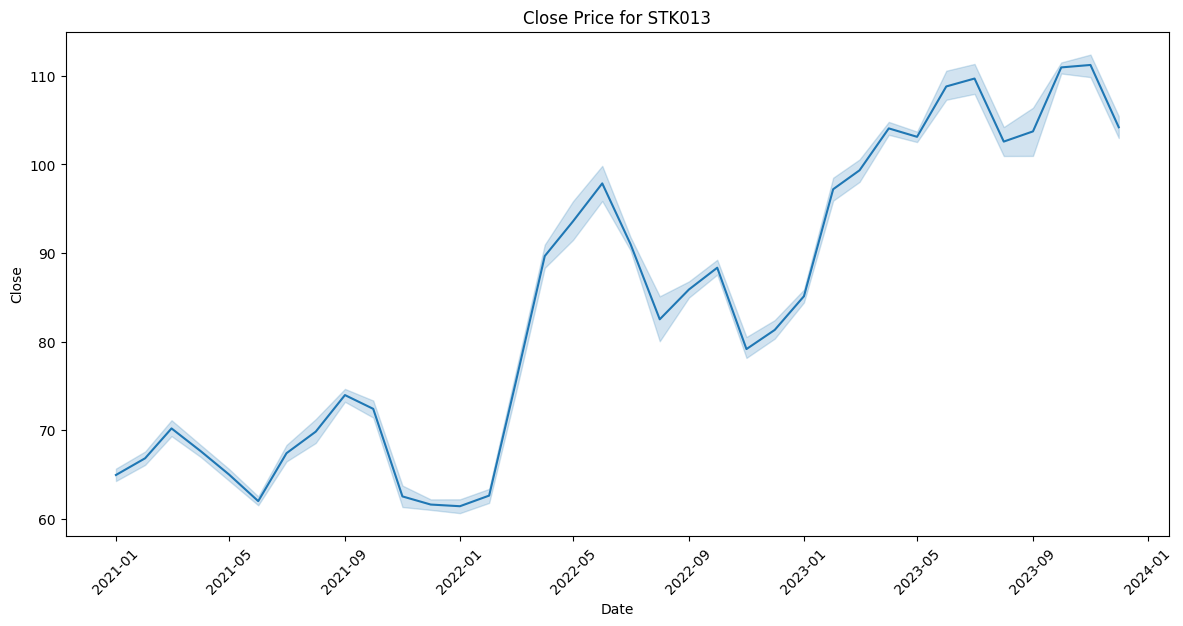

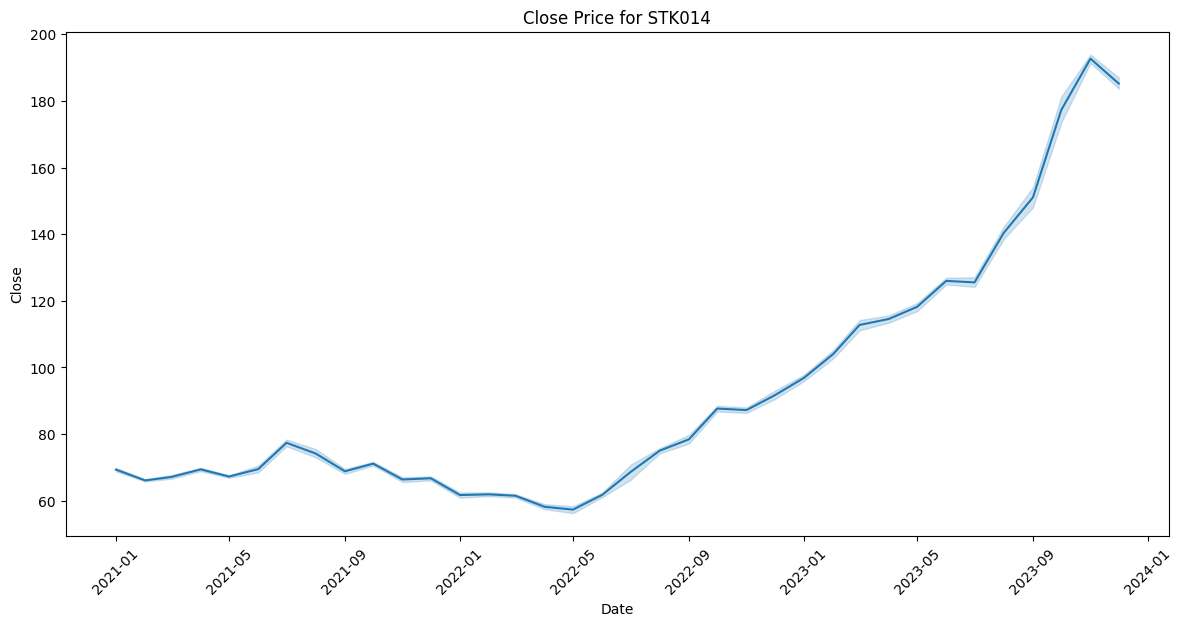

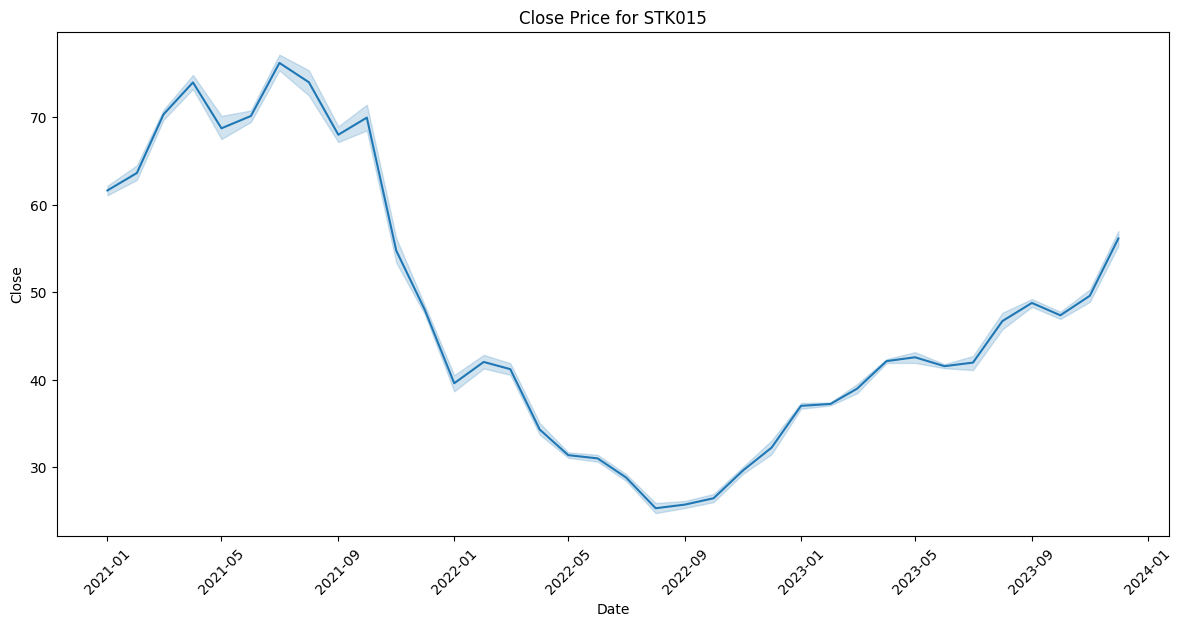

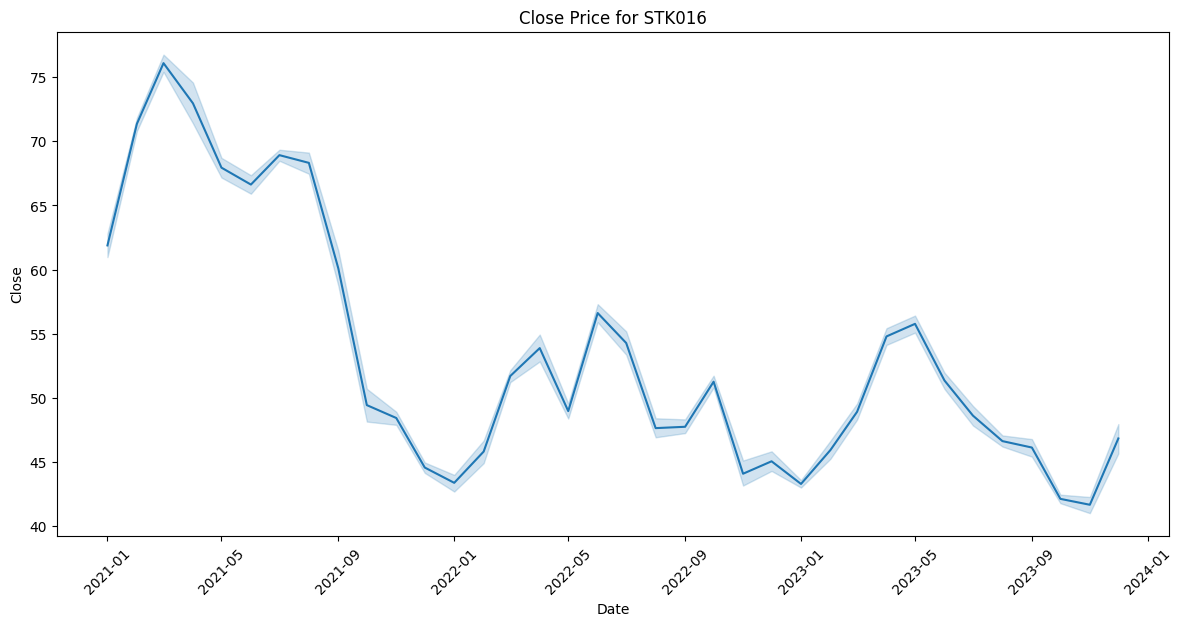

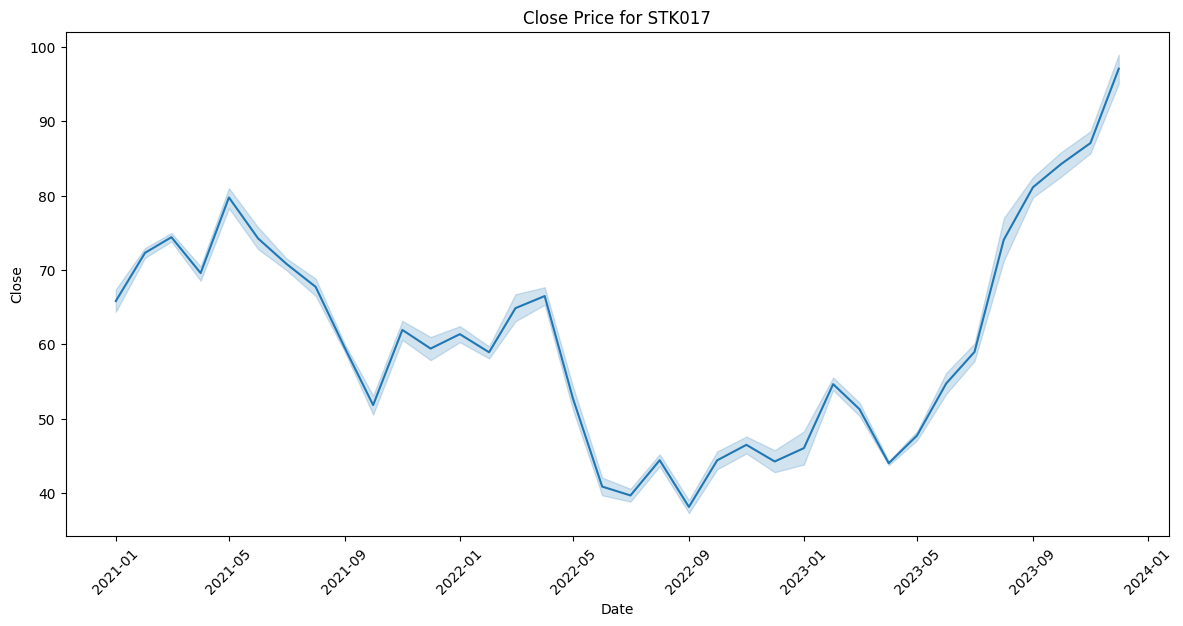

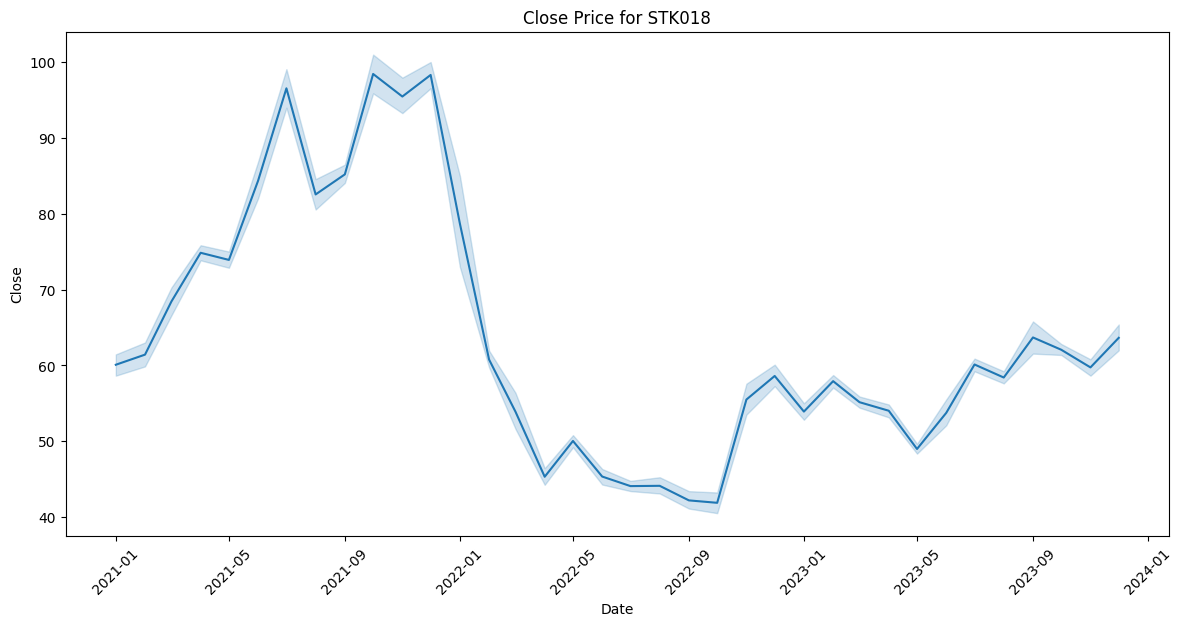

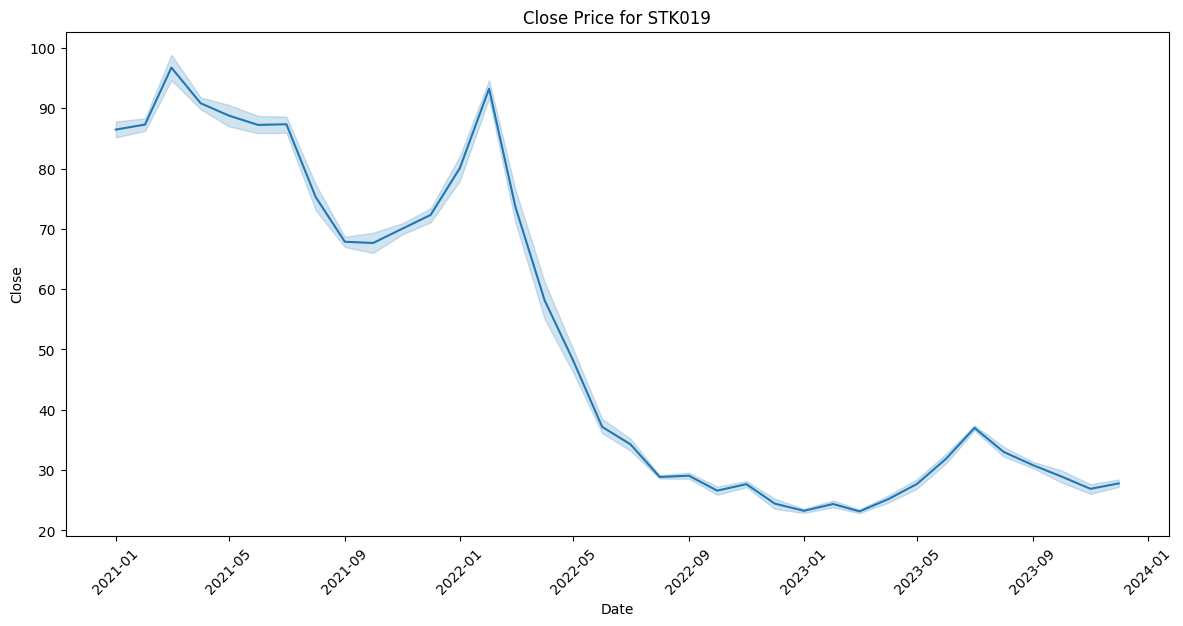

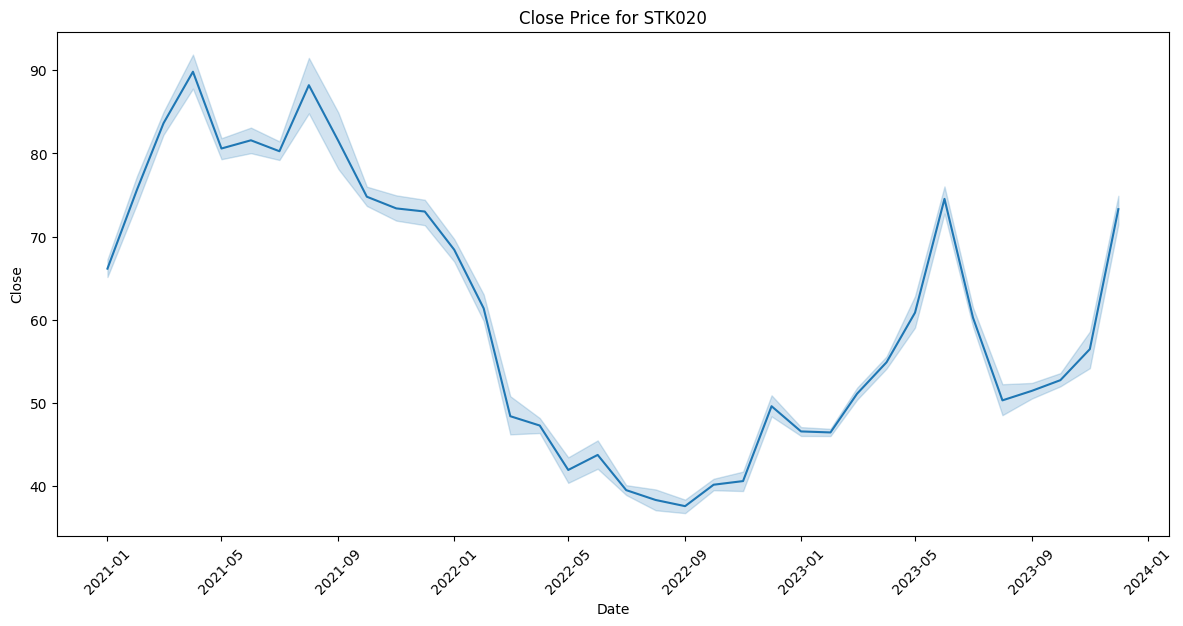

In [9]:
tickers = stk_prices['ticker'].unique()

for t in tickers:
    plt.figure(figsize=(12,6))
    sns.lineplot(data=stk_prices[stk_prices['ticker'] == t], 
                 x='mnth_yr', y='close')
    plt.title(f"Close Price for {t}")
    plt.xlabel("Date")
    plt.ylabel("Close")
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.show()


C:\Users\ofori\AppData\Local\Temp\ipykernel_18816\962844134.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  stk_prices2['close'].resample('M').mean().plot(figsize=(12,6))


<Axes: xlabel='date'>

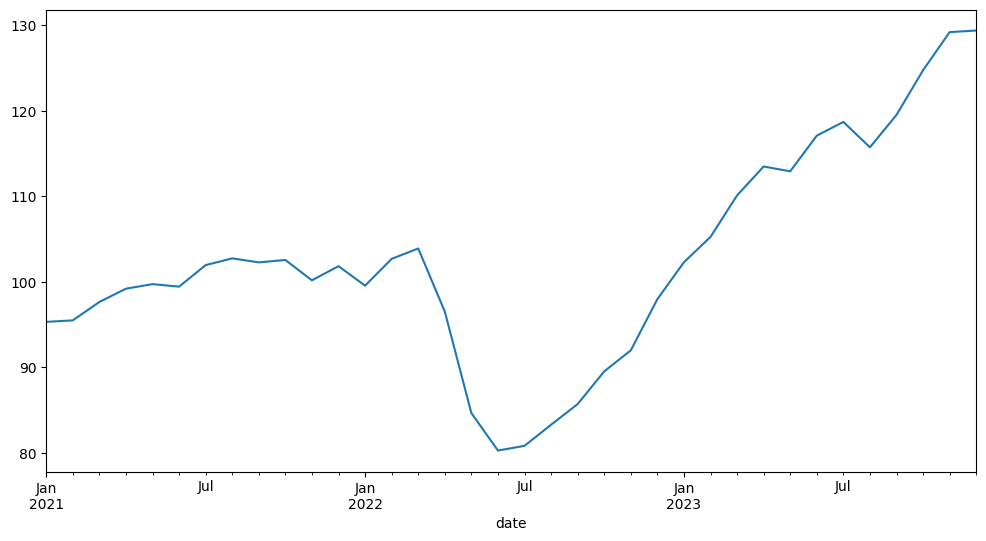